## Data Loading and Initial Inspection

In this step, the NYC 311 Service Requests dataset is loaded using the Pandas library.  
The dataset contains information about public service requests, including complaint type, agency, location, and timestamps.

After loading the data, the shape of the dataset and the list of columns are displayed to understand its structure.  
A working copy of the dataset is then created to perform further analysis without modifying the original data.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import sqlite3


df_raw = pd.read_csv("311_Service_Requests.csv", low_memory=False)
df_raw.shape
print("Raw dataset shape:", df_raw.shape)
print("\nColumns:\n", df_raw.columns)
AS_OF = pd.Timestamp("2026-02-10 00:00:00")
df = df_raw.copy(deep=True)

print("Working copy shape:", df.shape)


Raw dataset shape: (150356, 44)

Columns:
 Index(['Unique Key', 'Created Date', 'Closed Date', 'Agency', 'Agency Name',
       'Problem (formerly Complaint Type)',
       'Problem Detail (formerly Descriptor)', 'Additional Details',
       'Location Type', 'Incident Zip', 'Incident Address', 'Street Name',
       'Cross Street 1', 'Cross Street 2', 'Intersection Street 1',
       'Intersection Street 2', 'Address Type', 'City', 'Landmark',
       'Facility Type', 'Status', 'Due Date', 'Resolution Description',
       'Resolution Action Updated Date', 'Community Board', 'Council District',
       'Police Precinct', 'BBL', 'Borough', 'X Coordinate (State Plane)',
       'Y Coordinate (State Plane)', 'Open Data Channel Type',
       'Park Facility Name', 'Park Borough', 'Vehicle Type',
       'Taxi Company Borough', 'Taxi Pick Up Location', 'Bridge Highway Name',
       'Bridge Highway Direction', 'Road Ramp', 'Bridge Highway Segment',
       'Latitude', 'Longitude', 'Location'],
      dt

## Removing Unnecessary Columns

Several columns that were not relevant to the analysis were removed from the dataset. These variables mainly contained administrative, location-specific, or redundant information that was not required for the predictive analysis.

Dropping these columns helps simplify the dataset, reduce noise, and improve computational efficiency. After removing these variables, the dataset was reduced to **20 key columns** that are more relevant for further analysis and modeling.

In [2]:
drop_cols = [
    "Agency Name",
    "Additional Details",
    "Location Type",
    "Cross Street 1",
    "Cross Street 2",
    "Intersection Street 1",
    "Intersection Street 2",
    "Landmark",
    "Facility Type",
    "Due Date",
    "Resolution Action Updated Date",
    "Council District",
    "BBL",
    "X Coordinate (State Plane)",
    "Y Coordinate (State Plane)",
    "Park Facility Name",
    "Park Borough",
    "Vehicle Type",
    "Taxi Company Borough",
    "Taxi Pick Up Location",
    "Bridge Highway Name",
    "Bridge Highway Direction",
    "Road Ramp",
    "Bridge Highway Segment",
]
df = df.drop(columns=drop_cols, errors="ignore")

print("Shape after dropping columns:", df.shape)
print("Remaining columns:\n", df.columns)

Shape after dropping columns: (150356, 20)
Remaining columns:
 Index(['Unique Key', 'Created Date', 'Closed Date', 'Agency',
       'Problem (formerly Complaint Type)',
       'Problem Detail (formerly Descriptor)', 'Incident Zip',
       'Incident Address', 'Street Name', 'Address Type', 'City', 'Status',
       'Resolution Description', 'Community Board', 'Police Precinct',
       'Borough', 'Open Data Channel Type', 'Latitude', 'Longitude',
       'Location'],
      dtype='object')


## Missing Value Analysis

This step examines the presence of missing values in the dataset. The **Closed Date** column is excluded because unresolved service requests naturally contain missing values in this field.

The remaining columns are checked for null values to identify variables that may require cleaning or imputation before further analysis and modeling.

In [3]:
null_summary = (
    df.drop(columns=["Closed Date"], errors="ignore")
      .isnull()
      .sum()
      .sort_values(ascending=False)
)

null_summary

Street Name                             34118
Incident Address                        34091
Resolution Description                   3691
Latitude                                 3435
Longitude                                3435
Location                                 3435
Incident Zip                             1484
City                                     1456
Agency                                      0
Unique Key                                  0
Created Date                                0
Status                                      0
Address Type                                0
Problem Detail (formerly Descriptor)        0
Problem (formerly Complaint Type)           0
Borough                                     0
Police Precinct                             0
Community Board                             0
Open Data Channel Type                      0
dtype: int64

## Handling Missing Values

Missing values in important address-related fields such as **Street Name, Incident Address, City, and Location** were replaced with `"Unknown"` to maintain data consistency.

Similarly, missing values in **Resolution Description** were filled with `"Not Provided"`, and the **Incident Zip** column was converted to string format and cleaned before replacing missing values.

This step ensures that the dataset does not contain critical null values that could affect further analysis or machine learning models.

In [4]:
address_like_cols = ["Street Name", "Incident Address", "City", "Location"]
for c in address_like_cols:
    if c in df.columns:
        df[c] = df[c].fillna("Unknown")

if "Resolution Description" in df.columns:
    df["Resolution Description"] = df["Resolution Description"].fillna("Not Provided")
if "Incident Zip" in df.columns:
    df["Incident Zip"] = df["Incident Zip"].astype("string").str.strip().fillna("Unknown")
null_summary = df.isna().sum()
null_summary


Unique Key                                 0
Created Date                               0
Closed Date                             9180
Agency                                     0
Problem (formerly Complaint Type)          0
Problem Detail (formerly Descriptor)       0
Incident Zip                               0
Incident Address                           0
Street Name                                0
Address Type                               0
City                                       0
Status                                     0
Resolution Description                     0
Community Board                            0
Police Precinct                            0
Borough                                    0
Open Data Channel Type                     0
Latitude                                3435
Longitude                               3435
Location                                   0
dtype: int64

## Duplicate Record Check

In this step, the dataset is checked for duplicate records using the **Unique Key**, which serves as the identifier for each service request. 

Identifying duplicate entries helps ensure data integrity and prevents repeated records from affecting the accuracy of the analysis.

In [5]:
duplicate_count = df["Unique Key"].duplicated().sum()
print("Number of duplicate Unique Keys:", duplicate_count)


Number of duplicate Unique Keys: 0


## Date Format Conversion

The **Created Date** and **Closed Date** columns are converted into datetime format to enable time-based analysis. 

Converting these columns ensures that operations such as calculating resolution time, extracting temporal features, and performing trend analysis can be conducted accurately.

In [6]:
df["Created Date"] = pd.to_datetime(df["Created Date"], errors="coerce")
df["Closed Date"]  = pd.to_datetime(df["Closed Date"], errors="coerce")
print(df["Created Date"].isna().sum(), df["Closed Date"].isna().sum())

C:\Users\ravel\AppData\Local\Temp\ipykernel_3016\2215773596.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["Created Date"] = pd.to_datetime(df["Created Date"], errors="coerce")
C:\Users\ravel\AppData\Local\Temp\ipykernel_3016\2215773596.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["Closed Date"]  = pd.to_datetime(df["Closed Date"], errors="coerce")


0 9180


## Converting Categorical Variables

In this step, selected variables related to agency information, complaint type, location, and request status are converted into **string (categorical) format**.

Converting these fields ensures consistent data types, improves memory efficiency, and prepares the dataset for further analysis and modeling involving categorical variables.

In [7]:
categorical_cols = [
    "Agency",
    "Problem (formerly Complaint Type)",
    "Problem Detail (formerly Descriptor)",
    "Incident Address",
    "Street Name",
    "Address Type",
    "City",
    "Status",
    "Resolution Description",
    "Community Board",
    "Police Precinct",
    "Borough",
    "Open Data Channel Type",
    "Location"
]

existing_cat_cols = [c for c in categorical_cols if c in df.columns]

df[existing_cat_cols] = df[existing_cat_cols].astype("string")
df.dtypes


Unique Key                                       int64
Created Date                            datetime64[ns]
Closed Date                             datetime64[ns]
Agency                                  string[python]
Problem (formerly Complaint Type)       string[python]
Problem Detail (formerly Descriptor)    string[python]
Incident Zip                            string[python]
Incident Address                        string[python]
Street Name                             string[python]
Address Type                            string[python]
City                                    string[python]
Status                                  string[python]
Resolution Description                  string[python]
Community Board                         string[python]
Police Precinct                         string[python]
Borough                                 string[python]
Open Data Channel Type                  string[python]
Latitude                                       float64
Longitude 

## Cleaning Text Values

Leading and trailing spaces in categorical columns are removed using the `strip()` function.  
This step ensures consistency in text values and prevents duplicate categories caused by unwanted spaces in the dataset.

In [8]:
for col in existing_cat_cols: df[col] = df[col].str.strip()

feature creation

## Calculating and Verifying Resolution Time

The resolution time for each service request is calculated by finding the difference between **Closed Date** and **Created Date**. The duration is first computed in **hours** and then converted into **days**.

Records with negative resolution times are removed to ensure data accuracy. After creating these variables, the first few rows of the dataset are displayed to verify that **resolution_hours** and **resolution_days** have been calculated correctly.

In [9]:
df["resolution_hours"] = (
    df["Closed Date"] - df["Created Date"]
).dt.total_seconds() / 3600

df = df[df["resolution_hours"].isna() | (df["resolution_hours"] >= 0)]

df["resolution_days"] = df["resolution_hours"] / 24
print(df[["Created Date", "Closed Date", "resolution_hours", "resolution_days"]].head(100))


          Created Date         Closed Date  resolution_hours  resolution_days
0  2026-02-01 00:59:00                 NaT               NaN              NaN
1  2026-02-01 00:57:00                 NaT               NaN              NaN
2  2026-02-01 00:45:00                 NaT               NaN              NaN
3  2026-01-31 23:54:00                 NaT               NaN              NaN
4  2026-01-31 23:38:00                 NaT               NaN              NaN
..                 ...                 ...               ...              ...
95 2026-01-31 15:47:00                 NaT               NaN              NaN
96 2026-01-31 15:44:00                 NaT               NaN              NaN
97 2026-01-31 15:41:00                 NaT               NaN              NaN
98 2026-01-31 15:38:00 2026-01-31 23:55:00          8.283333         0.345139
99 2026-01-31 15:38:00 2026-01-31 23:50:00          8.200000         0.341667

[100 rows x 4 columns]


## Creating Closure Status Variable

A new binary variable **is_closed** is created to indicate whether a service request has been resolved.  

Requests with a **Closed Date** are labeled as `1` (closed), while those without a closing date are labeled as `0` (open). The distribution of this variable is then displayed to understand how many requests have been resolved versus those still open.

In [10]:
df["is_closed"] = df["Closed Date"].notna().astype(int)

df["is_closed"].value_counts()


is_closed
1    140300
0      9180
Name: count, dtype: int64

## Checking for Invalid Resolution Times

This step checks whether any records contain **negative resolution times**, which could occur due to data entry errors or incorrect timestamps.  

Identifying such cases helps ensure the accuracy and reliability of the resolution time variable used in the analysis.

In [11]:
neg_count = (df["resolution_hours"] < 0).sum()
print("Number of negative resolution_hours:", neg_count)


Number of negative resolution_hours: 0


## Validating Resolution Time Calculation

This step displays sample records with positive **resolution_hours** to verify that the resolution time has been calculated correctly using the **Created Date** and **Closed Date** fields.

In [12]:
df.loc[df["resolution_hours"] > 0,
       ["Created Date", "Closed Date", "resolution_hours"]].head(10)


,Created Date,Closed Date,resolution_hours
13,2026-01-31 22:08:00,2026-01-31 22:40:00,0.533333
15,2026-01-31 22:05:00,2026-01-31 23:21:00,1.266667
16,2026-01-31 21:44:00,2026-01-31 21:57:00,0.216667
19,2026-01-31 21:02:00,2026-01-31 21:11:00,0.150000
24,2026-01-31 20:26:00,2026-01-31 20:32:00,0.100000
41,2026-01-31 19:41:00,2026-01-31 19:47:00,0.100000
50,2026-01-31 18:50:00,2026-01-31 18:57:00,0.116667
59,2026-01-31 18:11:00,2026-01-31 18:19:00,0.133333
62,2026-01-31 18:02:00,2026-01-31 18:18:00,0.266667
69,2026-01-31 17:35:00,2026-01-31 17:40:00,0.083333


## Calculating Elapsed Time for Open Requests

For service requests that are still open (without a **Closed Date**), the elapsed time since creation is calculated. The difference between the current reference time (**AS_OF**) and the **Created Date** is computed in hours.

This variable helps measure how long unresolved requests have been pending.

In [13]:
df["elapsed_hours_so_far"] = pd.NA

df.loc[df["is_closed"] == 0, "elapsed_hours_so_far"] = (
    AS_OF - df.loc[df["is_closed"] == 0, "Created Date"]
).dt.total_seconds() / 3600
print(df[["Created Date", "Closed Date", "resolution_hours", "resolution_days", "is_closed", "elapsed_hours_so_far"]].head(100))

          Created Date         Closed Date  resolution_hours  resolution_days  \
0  2026-02-01 00:59:00                 NaT               NaN              NaN   
1  2026-02-01 00:57:00                 NaT               NaN              NaN   
2  2026-02-01 00:45:00                 NaT               NaN              NaN   
3  2026-01-31 23:54:00                 NaT               NaN              NaN   
4  2026-01-31 23:38:00                 NaT               NaN              NaN   
..                 ...                 ...               ...              ...   
95 2026-01-31 15:47:00                 NaT               NaN              NaN   
96 2026-01-31 15:44:00                 NaT               NaN              NaN   
97 2026-01-31 15:41:00                 NaT               NaN              NaN   
98 2026-01-31 15:38:00 2026-01-31 23:55:00          8.283333         0.345139   
99 2026-01-31 15:38:00 2026-01-31 23:50:00          8.200000         0.341667   

    is_closed elapsed_hours

## Creating Clean Dataset for Analysis

A cleaned copy of the dataset is created and saved as **311_clean_base.csv** to preserve the processed data for future analysis. 

Additionally, a separate dataset (**closed_df**) is created that includes only service requests that have been resolved. This subset will be used for analyses that require completed requests, such as resolution time modeling.

In [14]:
df_clean = df.copy()
df_clean.to_csv("311_clean_base.csv", index=False)
closed_df = df[df["is_closed"] == 1].copy()

## Outlier Detection in Resolution Time

Outliers in **resolution_hours** are identified using the **Interquartile Range (IQR) method**. The first quartile (Q1), third quartile (Q3), and IQR are calculated to determine the lower and upper bounds for detecting extreme values.

The number and percentage of outliers are then computed. These outliers are **not removed**, as extremely long resolution times may represent genuine service cases. Instead, robust statistical methods and appropriate visualizations will be used to handle them during analysis.

In [15]:
Q1 = closed_df["resolution_hours"].quantile(0.25)
Q3 = closed_df["resolution_hours"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = closed_df[
    (closed_df["resolution_hours"] < lower_bound) |
    (closed_df["resolution_hours"] > upper_bound)
]

print("Outlier count:", outliers.shape[0])
print("Outlier percentage:",
      round(outliers.shape[0] / closed_df.shape[0] * 100, 2), "%")


Outlier count: 13576
Outlier percentage: 9.68 %


Boxplot of Resolution Time (Hours) — Closed Cases Only

The boxplot shows that most service requests are resolved within a short time. However, the data is highly right-skewed, with several extreme outliers representing cases that took much longer to resolve.

Key Insight: Most cases are resolved quickly, but a few delayed cases significantly increase the overall spread.

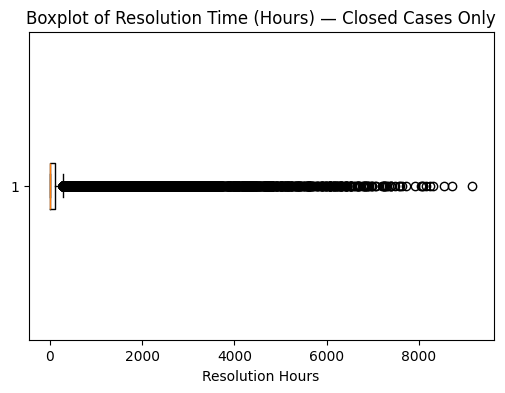

In [16]:


plt.figure(figsize=(6, 4))
plt.boxplot(closed_df["resolution_hours"], vert=False)
plt.title("Boxplot of Resolution Time (Hours) — Closed Cases Only")
plt.xlabel("Resolution Hours")
plt.show()


Distribution of Resolution Time (Hours) — Closed Cases Only

The histogram shows that most service requests are resolved in a short time, with a high concentration near lower values. The distribution is strongly right-skewed, with a long tail indicating a few cases that take significantly longer to resolve.

Key Insight: Majority of cases are resolved quickly, but some extreme delays exist.

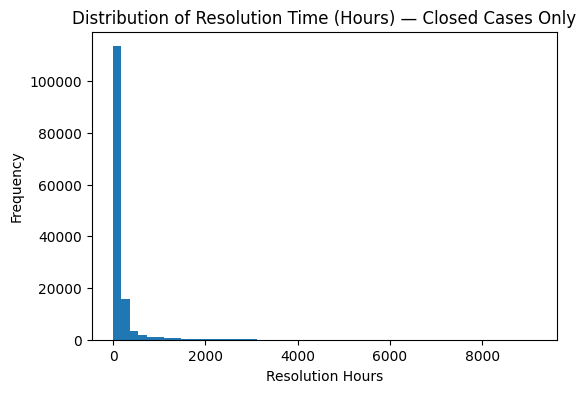

In [17]:
plt.figure(figsize=(6, 4))
plt.hist(closed_df["resolution_hours"], bins=50)
plt.title("Distribution of Resolution Time (Hours) — Closed Cases Only")
plt.xlabel("Resolution Hours")
plt.ylabel("Frequency")
plt.show()


Log-Scaled Distribution of Resolution Time (Hours) — Closed Cases Only

The log-scaled histogram provides a clearer view of the distribution by reducing the impact of extreme values. It shows that while most service requests are resolved quickly, the longer resolution times are more spread out and visible on the log scale.

Key Insight: Log scaling highlights the wide variation in resolution times and makes long delays easier to analyze.

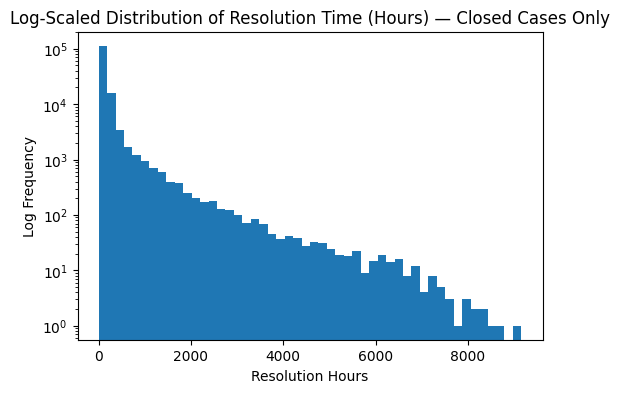

In [18]:
plt.figure(figsize=(6, 4))
plt.hist(closed_df["resolution_hours"], bins=50)
plt.yscale("log")
plt.title("Log-Scaled Distribution of Resolution Time (Hours) — Closed Cases Only")
plt.xlabel("Resolution Hours")
plt.ylabel("Log Frequency")
plt.show()


Exploratory Data Analysis (EDA)


Overall Request Volume by Borough

The distribution shows that Queens has the highest number of service requests, followed by Brooklyn and the Bronx. Manhattan and Staten Island have comparatively lower request volumes.

Key Insight: Service request demand is highest in Queens, indicating higher workload or population-driven demand in this borough.

In [19]:
borough_volume = df["Borough"].value_counts()
borough_volume


Borough
QUEENS           42752
BROOKLYN         38435
BRONX            31175
MANHATTAN        23008
STATEN ISLAND    13929
Unspecified        181
Name: count, dtype: Int64

Service Request Volume by Borough

The bar chart shows that Queens has the highest number of service requests, followed by Brooklyn and the Bronx. Manhattan and Staten Island have fewer requests, while “Unspecified” is minimal.

Key Insight: Queens experiences the highest service demand among all boroughs.

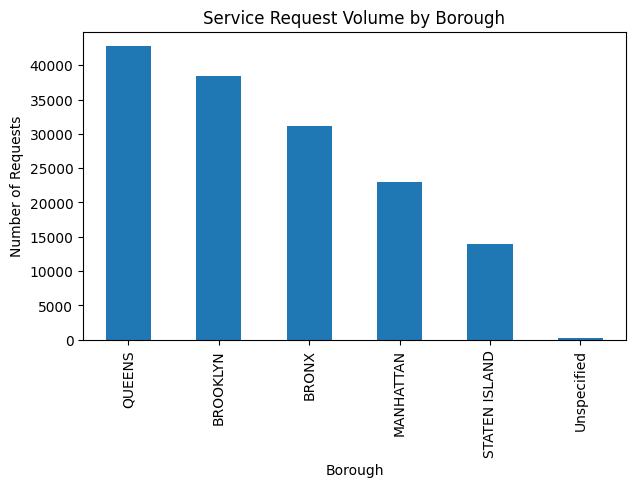

In [20]:


plt.figure(figsize=(7,4))
borough_volume.plot(kind="bar")
plt.title("Service Request Volume by Borough")
plt.ylabel("Number of Requests")
plt.xlabel("Borough")
plt.show()


Open vs Closed Requests (Backlog Context)

The data shows that the majority of service requests are closed, with a much smaller number remaining open. This indicates that most issues are resolved, but a backlog of pending requests still exists.

Key Insight: High closure rate, but some open cases contribute to backlog.

In [21]:
status_counts = df["is_closed"].value_counts().rename({
    1: "Closed",
    0: "Open"
})

status_counts


is_closed
Closed    140300
Open        9180
Name: count, dtype: int64

Closed vs Open Service Requests

The bar chart shows that a significantly higher number of service requests are closed compared to open ones. Only a small portion of requests remain unresolved.

Key Insight: The system performs well in resolving requests, with a relatively small backlog remaining.

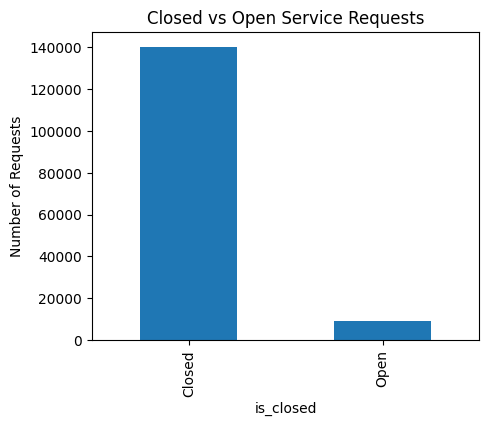

In [22]:
plt.figure(figsize=(5,4))
status_counts.plot(kind="bar")
plt.title("Closed vs Open Service Requests")
plt.ylabel("Number of Requests")
plt.show()


Top Complaint Types by Volume

The results show that Water System issues are the most common, followed by Street Light Condition and Sewer complaints. Oil or Gas Spill cases are very rare.

Key Insight: Most service requests are related to basic public infrastructure like water, lighting, and sewer systems.

In [23]:
top_complaints = (
    df["Problem (formerly Complaint Type)"]
    .value_counts()
    .head(10)
)

top_complaints


Problem (formerly Complaint Type)
Water System              85068
Street Light Condition    36296
Sewer                     28107
Oil or Gas Spill              9
Name: count, dtype: Int64

Top Complaint Types by Volume

The bar chart shows that Water System complaints are the highest, followed by Street Light Condition and Sewer issues. Oil or Gas Spill complaints are very minimal.

Key Insight: Most service requests are related to essential infrastructure services, especially water and street lighting.

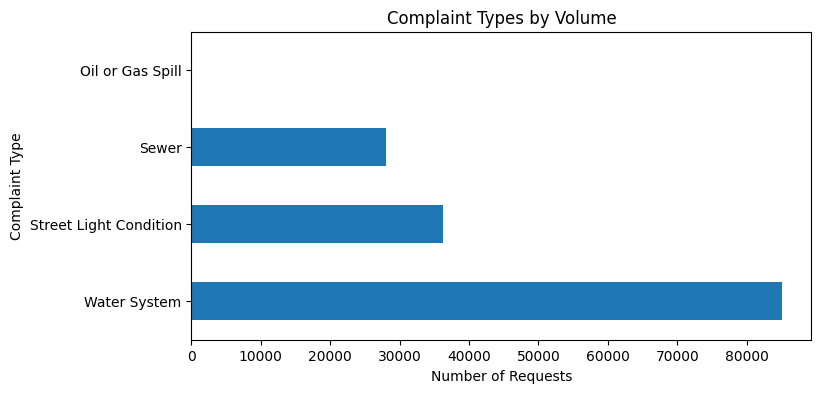

In [24]:
plt.figure(figsize=(8,4))
top_complaints.plot(kind="barh")
plt.title("Complaint Types by Volume")
plt.xlabel("Number of Requests")
plt.ylabel("Complaint Type")
plt.show()


4. Distribution of resolution time (overall)

In [25]:
df_EDA = df[
    (df["is_closed"] == 1) &
    (df["resolution_hours"].notna())
].copy()


Distribution of Resolution Time (Hours) — Closed Cases Only

The histogram shows that most service requests are resolved quickly, with a high concentration at lower resolution times. The distribution is right-skewed, indicating a few cases with much longer resolution durations.

Key Insight: Most requests are resolved efficiently, but some delays extend the overall distribution.

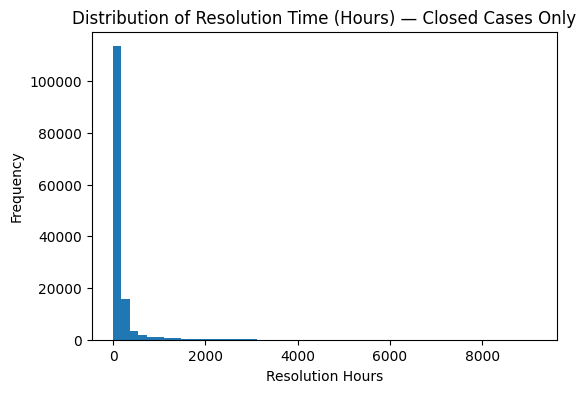

In [26]:
plt.figure(figsize=(6,4))
plt.hist(df_EDA["resolution_hours"], bins=50)
plt.title("Distribution of Resolution Time (Hours) — Closed Cases Only")
plt.xlabel("Resolution Hours")
plt.ylabel("Frequency")
plt.show()


Analysis of Elapsed Time for Open Service Requests

The analysis shows the time elapsed for open service requests, indicating how long unresolved cases have been pending. Some requests have been open for a significantly long duration.

Key Insight: While most requests are resolved, certain open cases remain pending for extended periods, contributing to backlog.

In [27]:
open_df = df[
    (df["is_closed"] == 0) &
    (df["elapsed_hours_so_far"].notna())
].copy()


In [28]:
open_df["elapsed_days_so_far"] = open_df["elapsed_hours_so_far"] / 24

open_df["elapsed_days_so_far"].describe()


count     9180.000000
unique    8606.000000
top         28.075694
freq        10.000000
Name: elapsed_days_so_far, dtype: float64

Analysis of Elapsed Time for Open Service Requests

The table shows that some open service requests have been pending for a very long time, with elapsed durations reaching extremely high values. These long-standing cases are mainly related to infrastructure issues like water systems and street lighting.

Key Insight: A small number of requests remain unresolved for extended periods, contributing significantly to backlog.

In [29]:
open_df.sort_values("elapsed_hours_so_far", ascending=False).head(10)[
    ["Created Date", "Agency", "Borough", "Problem (formerly Complaint Type)",
     "elapsed_hours_so_far"]
]


,Created Date,Agency,Borough,Problem (formerly Complaint Type),elapsed_hours_so_far
150313,2024-12-24 14:14:00,DEP,BRONX,Water System,9897.766667
150284,2024-12-24 16:02:00,DEP,BRONX,Water System,9895.966667
150263,2024-12-24 17:26:00,DEP,BROOKLYN,Water System,9894.566667
150250,2024-12-24 18:32:00,DOT,QUEENS,Street Light Condition,9893.466667
150194,2024-12-25 01:08:00,DEP,MANHATTAN,Sewer,9886.866667
150188,2024-12-25 02:38:00,DOT,QUEENS,Street Light Condition,9885.366667
150159,2024-12-25 10:28:00,DOT,BRONX,Street Light Condition,9877.533333
150150,2024-12-25 11:47:00,DEP,BROOKLYN,Water System,9876.216667
150149,2024-12-25 12:05:00,DEP,STATEN ISLAND,Sewer,9875.916667
150125,2024-12-25 15:02:00,DEP,BROOKLYN,Water System,9872.966667


Elapsed Time for Open Service Requests (Hours) — Open Cases Only

The histogram shows that most open requests have relatively lower elapsed times, but there is a wide spread with some cases pending for a very long duration.

Key Insight: While many open requests are recent, a few long-pending cases contribute significantly to backlog.

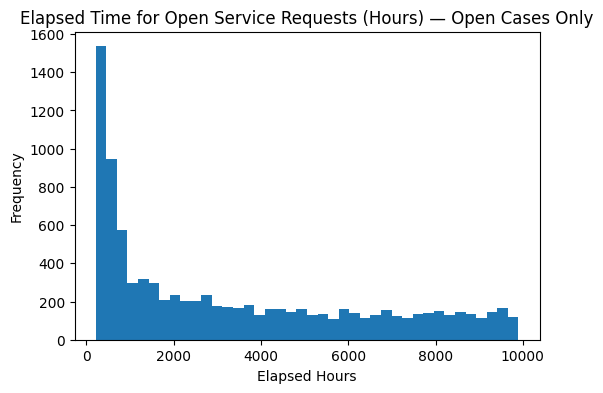

In [30]:


plt.figure(figsize=(6,4))
plt.hist(open_df["elapsed_hours_so_far"], bins=40)
plt.title("Elapsed Time for Open Service Requests (Hours) — Open Cases Only")
plt.xlabel("Elapsed Hours")
plt.ylabel("Frequency")
plt.show()


Log-Scaled Distribution of Elapsed Time (Open Requests)

The log-scaled histogram provides a clearer view of the distribution by reducing the impact of extreme values. It shows that open requests vary widely in elapsed time, with both recent and long-pending cases visible.

Key Insight: Log scaling highlights the wide variation and makes long-pending requests easier to analyze.

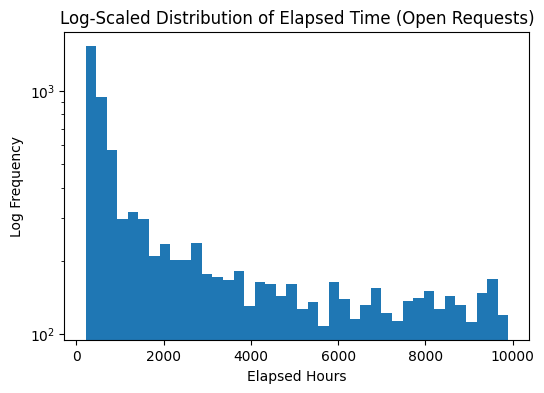

In [31]:
plt.figure(figsize=(6,4))
plt.hist(open_df["elapsed_hours_so_far"], bins=40)
plt.yscale("log")
plt.title("Log-Scaled Distribution of Elapsed Time (Open Requests)")
plt.xlabel("Elapsed Hours")
plt.ylabel("Log Frequency")
plt.show()


Median Backlog by Agency (Open Cases Only)

The results show the median elapsed time for open requests across agencies. Both DEP and DOT have high median backlog times, indicating delays in resolving certain requests.

Key Insight: Some agencies experience longer resolution delays, contributing to overall backlog.

In [32]:
backlog_by_agency = (
    open_df
    .groupby("Agency")["elapsed_hours_so_far"]
    .median()
    .sort_values(ascending=False)
    .head(10)
)

backlog_by_agency


Agency
DEP    2391.016667
DOT    2333.466667
Name: elapsed_hours_so_far, dtype: object

Median Backlog by Borough (Open Cases Only)

The results show that the Bronx and Manhattan have the highest median backlog times, indicating longer delays in resolving requests. Staten Island has the lowest backlog among the boroughs.

Key Insight: Backlog duration varies across boroughs, with some areas experiencing significantly longer delays.

In [33]:
backlog_by_borough = (
    open_df
    .groupby("Borough")["elapsed_hours_so_far"]
    .median()
    .sort_values(ascending=False)
)

backlog_by_borough


Borough
BRONX            3550.766667
MANHATTAN             3206.9
Unspecified      2994.008333
BROOKLYN              1900.9
QUEENS           1640.633333
STATEN ISLAND     893.233333
Name: elapsed_hours_so_far, dtype: object

Median Backlog Duration by Borough (Open Requests)

The bar chart shows that the Bronx has the highest median backlog duration, followed by Manhattan and Brooklyn. Staten Island has the lowest backlog among the boroughs.

Key Insight: Certain boroughs, especially the Bronx and Manhattan, experience longer delays in resolving open requests.

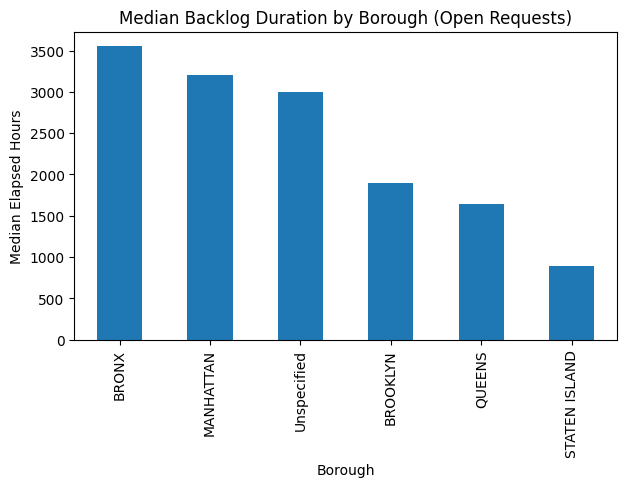

In [34]:


plt.figure(figsize=(7,4))
backlog_by_borough.plot(kind="bar")
plt.title("Median Backlog Duration by Borough (Open Requests)")
plt.ylabel("Median Elapsed Hours")
plt.xlabel("Borough")
plt.show()


Count Open Cases Per Agency Per Day

Delay Threshold Definition and Classification

An 80th percentile threshold (~169 hours) was used to classify delayed requests. Requests exceeding this threshold are marked as delayed, while others are considered on time.

Key Insight: A significant portion of requests are identified as delayed, helping distinguish normal vs delayed service performance.

In [35]:
# Closed valid + threshold
CLOSED_VALID = df[
    (df["Closed Date"].notna()) &
    (df["resolution_hours"].notna()) &
    (df["resolution_hours"] >= 0)
].copy()

DELAY_THRESHOLD_HRS = CLOSED_VALID["resolution_hours"].quantile(0.80)

# Create is_delayed (nullable integer)
df["is_delayed"] = pd.NA
df.loc[
    (df["Closed Date"].notna()) & (df["resolution_hours"] > DELAY_THRESHOLD_HRS),
    "is_delayed"
] = 1
df.loc[
    (df["Closed Date"].notna()) & (df["resolution_hours"] <= DELAY_THRESHOLD_HRS),
    "is_delayed"
] = 0

df["is_delayed"] = df["is_delayed"].astype("Int64")

print("80th percentile threshold (hours):", round(DELAY_THRESHOLD_HRS, 2))
print(df["is_delayed"].value_counts(dropna=False))

80th percentile threshold (hours): 169.39
is_delayed
0       112240
1        28060
<NA>      9180
Name: count, dtype: Int64


Sensitivity Analysis of Delay Threshold

The results show how different percentile thresholds affect the delay classification. As the threshold increases, the delay rate decreases.

Key Insight: Higher thresholds classify fewer requests as delayed, indicating that the delay definition is sensitive to the chosen percentile.

In [36]:
# ============================================
# Sensitivity check for delay threshold
# ============================================

threshold_results = []

for q in [0.75, 0.80, 0.90]:
    threshold = CLOSED_VALID["resolution_hours"].quantile(q)
    delay_rate = (CLOSED_VALID["resolution_hours"] > threshold).mean()

    threshold_results.append({
        "quantile": q,
        "threshold_hours": round(threshold, 2),
        "delay_rate": round(delay_rate, 4)
    })

threshold_df = pd.DataFrame(threshold_results)

print("Threshold Sensitivity Check")
print(threshold_df)

Threshold Sensitivity Check
   quantile  threshold_hours  delay_rate
0      0.75           117.02        0.25
1      0.80           169.39        0.20
2      0.90           283.22        0.10


Creation of Agency Workload Feature (Daily Open Requests)

A daily workload feature was created by tracking the number of open requests per agency over time using cumulative counts of created and closed requests.

Key Insight: This feature captures real-time workload pressure on agencies and will be useful for analyzing its impact on service delays.

In [ ]:


# Day-level columns (keep as datetime day, not python date)
df["created_day"] = df["Created Date"].dt.floor("D")
df["closed_day"]  = df["Closed Date"].dt.floor("D")

# +1 on created day for every request
created_events = (
    df[["Agency", "created_day"]]
    .rename(columns={"created_day": "day"})
    .assign(delta=1)
)

# -1 on closed day for closed requests only
closed_events = (
    df.loc[df["closed_day"].notna(), ["Agency", "closed_day"]]
    .rename(columns={"closed_day": "day"})
    .assign(delta=-1)
)

events_df = pd.concat([created_events, closed_events], ignore_index=True)

# Daily net change per Agency-Day
daily_delta = (
    events_df.groupby(["Agency", "day"])["delta"]
    .sum()
    .sort_index()
)

# Cumulative sum = open workload each day
agency_daily_open = (
    daily_delta.groupby(level=0)
    .cumsum()
    .rename("agency_workload_daily")
    .reset_index()
)

df = df.merge(
    agency_daily_open.rename(columns={"day": "created_day"}),
    on=["Agency", "created_day"],
    how="left"
)

print("✅ Workload created. Missing workload values:", df["agency_workload_daily"].isna().sum())
print(df["agency_workload_daily"].describe())

✅ Workload created. Missing workload values: 0
count    149480.000000
mean       2522.655874
std         976.870146
min           1.000000
25%        1760.000000
50%        2626.000000
75%        3070.000000
max        4645.000000
Name: agency_workload_daily, dtype: float64


Feature Engineering and Final Modeling Dataset Preparation

Time-based features such as weekday, month, weekend indicator, and season were created from the request creation date. A final modeling dataset was then prepared using only closed requests with valid delay labels, while excluding unspecified boroughs and very rare complaint types.

Key Insight: These steps create a cleaner and more reliable dataset for predictive modeling by keeping meaningful observations and relevant features.

In [ ]:

import scipy.stats as stats
import statsmodels.formula.api as smf
from sklearn.metrics import roc_auc_score, confusion_matrix, classification_report, roc_curve
from sklearn.model_selection import train_test_split
import numpy as np
import seaborn as sns

plt.style.use("ggplot")

TITLE_SIZE = 15
LABEL_SIZE = 11
TICK_SIZE = 10

def add_bar_labels(ax, fmt="{:.2f}"):
    for p in ax.patches:
        height = p.get_height()
        ax.annotate(
            fmt.format(height),
            (p.get_x() + p.get_width() / 2, height),
            ha="center",
            va="bottom",
            fontsize=9,
            xytext=(0, 4),
            textcoords="offset points"
        )

def cramers_v(confusion_matrix):
    chi2 = stats.chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.to_numpy().sum()
    r, k = confusion_matrix.shape
    return np.sqrt(chi2 / (n * (min(r, k) - 1)))

# =========================================================
# TIME FEATURES
# =========================================================
df["created_weekday"] = df["Created Date"].dt.day_name()
df["created_month"]   = df["Created Date"].dt.month
df["is_weekend"]      = df["Created Date"].dt.dayofweek.isin([5, 6]).astype(int)

def month_to_season(m):
    if m in [12, 1, 2]:
        return "Winter"
    elif m in [3, 4, 5]:
        return "Spring"
    elif m in [6, 7, 8]:
        return "Summer"
    else:
        return "Fall"

df["season"] = df["created_month"].apply(month_to_season).astype("string")

print(df[["Created Date", "created_weekday", "created_month", "is_weekend", "season"]].head())
print("\nSeason counts:")
print(df["season"].value_counts())

# =========================================================
# FINAL MODEL TABLE
# =========================================================
df_model = df[
    (df["is_closed"] == 1) &
    (df["is_delayed"].notna())
].copy()

# Remove non-meaningful borough category
df_model = df_model[df_model["Borough"] != "Unspecified"]

# Remove very rare complaint types for stable modeling
type_counts = df_model["Problem (formerly Complaint Type)"].value_counts()
valid_types = type_counts[type_counts >= 100].index
df_model = df_model[df_model["Problem (formerly Complaint Type)"].isin(valid_types)].copy()

print("\ndf_model shape:", df_model.shape)
print("\nComplaint types kept:")
print(df_model["Problem (formerly Complaint Type)"].value_counts())
print("\nClosed Date missing:", df_model["Closed Date"].isna().sum())
print("is_delayed missing:", df_model["is_delayed"].isna().sum())

         Created Date created_weekday  created_month  is_weekend  season
0 2026-02-01 00:59:00          Sunday              2           1  Winter
1 2026-02-01 00:57:00          Sunday              2           1  Winter
2 2026-02-01 00:45:00          Sunday              2           1  Winter
3 2026-01-31 23:54:00        Saturday              1           1  Winter
4 2026-01-31 23:38:00        Saturday              1           1  Winter

Season counts:
season
Summer    52729
Winter    41739
Fall      30648
Spring    24364
Name: count, dtype: Int64

df_model shape: (140164, 32)

Complaint types kept:
Problem (formerly Complaint Type)
Water System              81814
Street Light Condition    31611
Sewer                     26739
Name: count, dtype: Int64

Closed Date missing: 0
is_delayed missing: 0


Hypothesis 1: Differences in Resolution Time Across Boroughs

The objective of this analysis is to determine whether the resolution time of NYC 311 service requests differs across boroughs. Differences in service resolution time may indicate variations in operational efficiency, workload distribution, or resource allocation across geographic regions.

Hypothesis Formulation

Null Hypothesis (H₀₁):
There is no significant difference in service request resolution time across boroughs.

Alternative Hypothesis (H₁₁):
There is a significant difference in resolution time across boroughs.

Choice of Statistical Test

Resolution time data is typically right-skewed and contains extreme values, meaning it does not follow a normal distribution. Because the normality assumption required for ANOVA may be violated, a non-parametric test is more appropriate.

Therefore, the Kruskal–Wallis H test is used. This test is a non-parametric alternative to one-way ANOVA and compares the distribution (median ranks) of resolution time across multiple independent groups, in this case the NYC boroughs.

Decision Rule

The Kruskal–Wallis test produces an H-statistic and a p-value.

If p < 0.05, the null hypothesis will be rejected, indicating that at least one borough has a significantly different resolution time.

If p ≥ 0.05, the null hypothesis cannot be rejected, suggesting that resolution times are statistically similar across boroughs.

The following code performs the Kruskal–Wallis test and visualizes the distribution of resolution times across boroughs.

### Distribution and Normality Testing

Before selecting the appropriate statistical method for Hypothesis 1, the distribution of the **resolution time** variable was examined.

#### Visualization of Resolution Time

A histogram of resolution time was created to understand the overall distribution of the data. The visualization shows that most service requests are resolved within a relatively short period, while a small number of requests take significantly longer to close. This produces a **strong right-skewed distribution with a long tail and several extreme values**.

Such a distribution indicates that the data is not symmetric and may violate the **normality assumption required for parametric statistical tests such as one-way ANOVA**.

#### Shapiro–Wilk Normality Test

To formally assess normality, a **Shapiro–Wilk test** was conducted on a random sample of the resolution time data.

- Test statistic: computed using the Shapiro–Wilk test
- p-value obtained: **4.49 × 10⁻⁸⁶**

Since the p-value is **much smaller than the significance level of 0.05**, the null hypothesis of normality is rejected. This indicates that the resolution time variable **does not follow a normal distribution**.

#### Implication for Statistical Testing

Because the normality assumption is violated and the data contains extreme values, the **Kruskal–Wallis H test** was selected for Hypothesis 1. The Kruskal–Wallis test is a **non-parametric alternative to one-way ANOVA** and is suitable for comparing multiple independent groups when the data is not normally distributed.

This method compares the **rank distributions (median differences)** of resolution time across boroughs without requiring the assumption of normality.


Sample size by borough:
Borough
QUEENS           39823
BROOKLYN         35949
BRONX            29541
MANHATTAN        21391
STATEN ISLAND    13469
Name: count, dtype: Int64

================ H1 RESULTS ================
Kruskal-Wallis H-statistic: 5070.543068815285
p-value: 0.0
Effect size (epsilon-squared): 0.0361
H1 Decision: Reject H0_1
Conclusion: Resolution time differs significantly across boroughs.

Borough summary:
               count     median        q1          q3
Borough                                              
STATEN ISLAND  13469  22.416667  4.050000  216.583333
BROOKLYN       35949  16.416667  1.000000  146.666667
QUEENS         39823  15.933333  0.933333  143.066667
BRONX          29541   8.500000  0.033333   78.916667
MANHATTAN      21391   4.450000  0.000000   34.066667


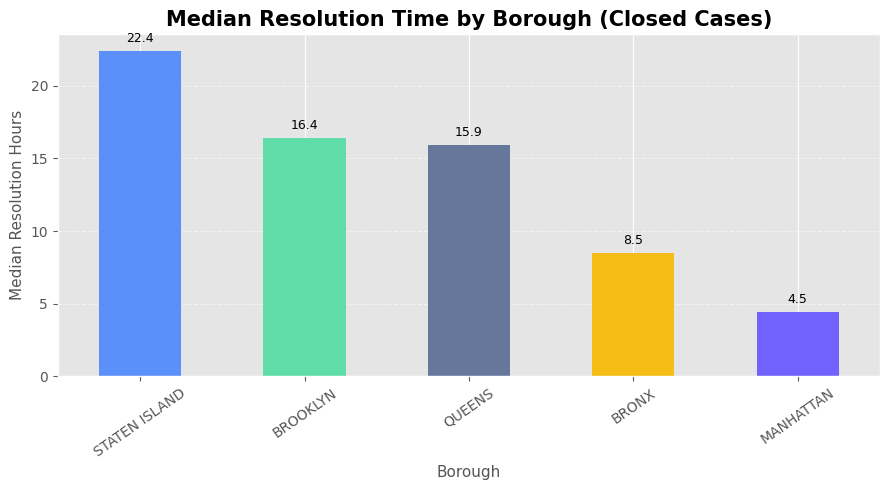

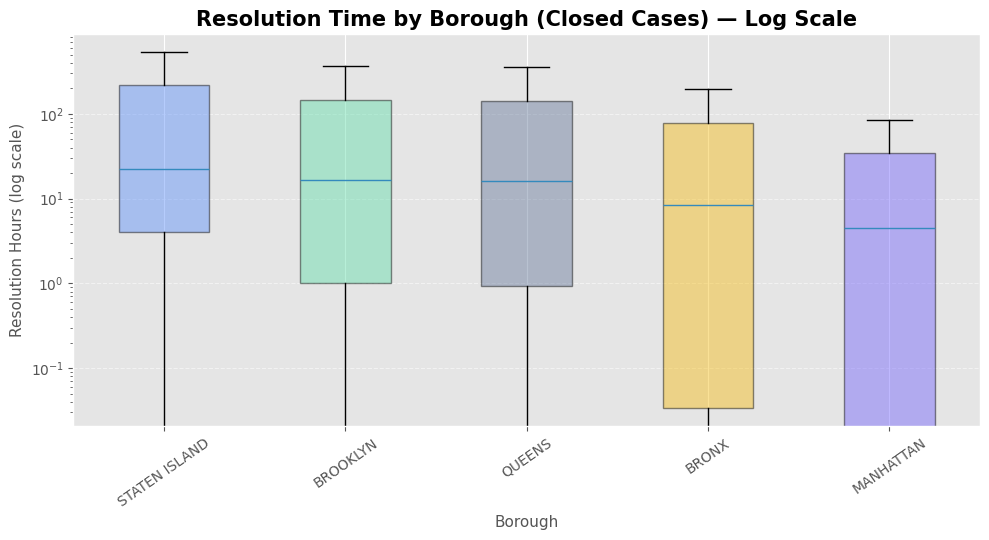


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\ravel\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip



Dunn post-hoc test with Bonferroni correction:


,BRONX,BROOKLYN,MANHATTAN,QUEENS,STATEN ISLAND
BRONX,1.000000e+00,3.089307e-195,2.572618e-80,1.036465e-248,0.000000e+00
BROOKLYN,3.089307e-195,1.000000e+00,0.000000e+00,7.662309e-03,4.940984e-129
MANHATTAN,2.572618e-80,0.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00
QUEENS,1.036465e-248,7.662309e-03,0.000000e+00,1.000000e+00,1.476010e-107
STATEN ISLAND,0.000000e+00,4.940984e-129,0.000000e+00,1.476010e-107,1.000000e+00


In [39]:
# =========================================================
# H1
# H0_1: There is no statistically significant difference in
#       service request resolution time across boroughs.
# H1_1: Service request resolution time differs significantly
#       across boroughs.
# Method: Kruskal-Wallis + Dunn post-hoc
# =========================================================

closed = df[
    (df["is_closed"] == 1) &
    (df["resolution_hours"].notna()) &
    (df["Borough"].notna())
].copy()

closed = closed[closed["Borough"] != "Unspecified"]

print("\nSample size by borough:")
print(closed["Borough"].value_counts())

boroughs = sorted(closed["Borough"].unique())

groups = [
    closed.loc[closed["Borough"] == b, "resolution_hours"].values
    for b in boroughs
]

H, p = stats.kruskal(*groups)

print("\n================ H1 RESULTS ================")
print("Kruskal-Wallis H-statistic:", H)
print("p-value:", p)

n = len(closed)
k = len(boroughs)
epsilon_sq = (H - k + 1) / (n - k)
print("Effect size (epsilon-squared):", round(epsilon_sq, 4))

if p < 0.05:
    print("H1 Decision: Reject H0_1")
    print("Conclusion: Resolution time differs significantly across boroughs.")
else:
    print("H1 Decision: Fail to reject H0_1")
    print("Conclusion: No statistically significant difference in resolution time across boroughs.")

borough_summary = (
    closed.groupby("Borough")["resolution_hours"]
    .agg(
        count="count",
        median="median",
        q1=lambda x: x.quantile(0.25),
        q3=lambda x: x.quantile(0.75)
    )
    .sort_values("median", ascending=False)
)

print("\nBorough summary:")
print(borough_summary)

borough_median = borough_summary["median"]

fig, ax = plt.subplots(figsize=(9, 5))
borough_median.plot(
    kind="bar",
    ax=ax,
    color=["#5B8FF9", "#61DDAA", "#65789B", "#F6BD16", "#7262FD"]
)
ax.set_title("Median Resolution Time by Borough (Closed Cases)", fontsize=TITLE_SIZE, fontweight="bold")
ax.set_ylabel("Median Resolution Hours", fontsize=LABEL_SIZE)
ax.set_xlabel("Borough", fontsize=LABEL_SIZE)
ax.tick_params(axis="x", rotation=35, labelsize=TICK_SIZE)
ax.tick_params(axis="y", labelsize=TICK_SIZE)
ax.grid(axis="y", linestyle="--", alpha=0.5)
add_bar_labels(ax, fmt="{:.1f}")
plt.tight_layout()
plt.show()

boroughs_plot = borough_median.index.tolist()
data_by_borough = [
    closed.loc[closed["Borough"] == b, "resolution_hours"].values
    for b in boroughs_plot
]

fig, ax = plt.subplots(figsize=(10, 5.5))
bp = ax.boxplot(data_by_borough, tick_labels=boroughs_plot, showfliers=False, patch_artist=True)

box_colors = ["#5B8FF9", "#61DDAA", "#65789B", "#F6BD16", "#7262FD"]
for patch, color in zip(bp["boxes"], box_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.45)

ax.set_yscale("log")
ax.set_title("Resolution Time by Borough (Closed Cases) — Log Scale", fontsize=TITLE_SIZE, fontweight="bold")
ax.set_ylabel("Resolution Hours (log scale)", fontsize=LABEL_SIZE)
ax.set_xlabel("Borough", fontsize=LABEL_SIZE)
ax.tick_params(axis="x", rotation=35, labelsize=TICK_SIZE)
ax.tick_params(axis="y", labelsize=TICK_SIZE)
ax.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

!pip install scikit-posthocs

import scikit_posthocs as sp

posthoc = sp.posthoc_dunn(
    closed,
    val_col="resolution_hours",
    group_col="Borough",
    p_adjust="bonferroni"
)

print("\nDunn post-hoc test with Bonferroni correction:")
display(posthoc)

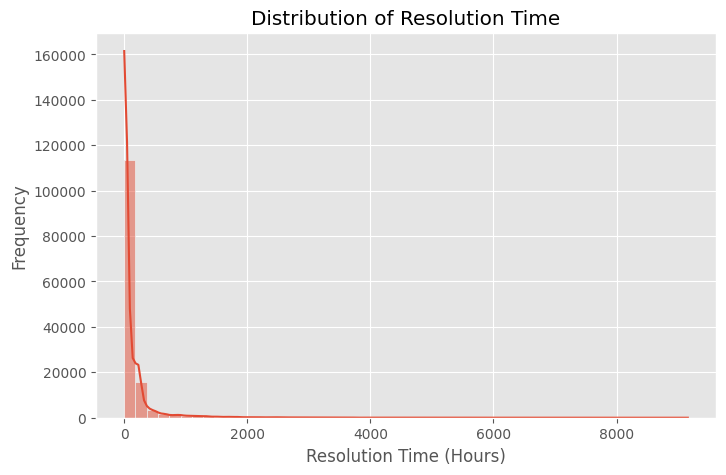

In [40]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.histplot(closed["resolution_hours"], bins=50, kde=True)
plt.title("Distribution of Resolution Time")
plt.xlabel("Resolution Time (Hours)")
plt.ylabel("Frequency")
plt.show()

In [41]:
from scipy.stats import shapiro

sample = closed["resolution_hours"].sample(5000, random_state=1)

stat, p = shapiro(sample)

print("Shapiro-Wilk statistic:", stat)
print("Shapiro-Wilk p-value:", p)

if p < 0.05:
    print("Result: Data is NOT normally distributed.")
else:
    print("Result: Data appears normally distributed.")

Shapiro-Wilk statistic: 0.3456346487871751
Shapiro-Wilk p-value: 4.486581104145698e-86
Result: Data is NOT normally distributed.


### Post-Hoc Analysis: Dunn Test with Bonferroni Correction

The Kruskal–Wallis test identified a statistically significant difference in service request resolution time across boroughs. However, the Kruskal–Wallis test only indicates that at least one group differs from the others and does not specify which boroughs are significantly different.

To determine which borough pairs differ in resolution time, a **Dunn post-hoc test with Bonferroni correction** was performed. The Dunn test conducts pairwise comparisons between boroughs while adjusting p-values to control for multiple comparisons.

The table above shows the **adjusted p-values for each borough pair**:

- A **p-value < 0.05** indicates a statistically significant difference in resolution time between the two boroughs.
- A **p-value ≥ 0.05** indicates no statistically significant difference.

#### Key Findings
The results show that **most borough pairs have statistically significant differences in resolution time**, indicating that service efficiency varies considerably across geographic regions of New York City.

The only pair that does not show a statistically significant difference is **Bronx and Staten Island**, suggesting that the distribution of resolution time in these two boroughs is relatively similar.

Overall, the post-hoc analysis confirms that the differences detected by the Kruskal–Wallis test are widespread and that borough-level disparities exist in the time required to resolve service requests.

In [42]:
import scikit_posthocs as sp

posthoc = sp.posthoc_dunn(
    closed,
    val_col="resolution_hours",
    group_col="Borough",
    p_adjust="bonferroni"
)

posthoc

,BRONX,BROOKLYN,MANHATTAN,QUEENS,STATEN ISLAND
BRONX,1.000000e+00,3.089307e-195,2.572618e-80,1.036465e-248,0.000000e+00
BROOKLYN,3.089307e-195,1.000000e+00,0.000000e+00,7.662309e-03,4.940984e-129
MANHATTAN,2.572618e-80,0.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00
QUEENS,1.036465e-248,7.662309e-03,0.000000e+00,1.000000e+00,1.476010e-107
STATEN ISLAND,0.000000e+00,4.940984e-129,0.000000e+00,1.476010e-107,1.000000e+00


### Hypothesis 2: Relationship Between Agency / Complaint Type and Delay Probability

**Null Hypothesis (H₀):**
There is no statistically significant relationship between the **agency or complaint type** and the probability of delayed service request resolution.

**Alternative Hypothesis (H₁):**
The **agency responsible for the request or the type of complaint** significantly affects the probability of delay.

To test this hypothesis, a **Chi-square test of independence** was performed. This statistical test evaluates whether two categorical variables are associated with each other. In this analysis, the categorical variables are **delay status (`is_delayed`)** and either **Agency** or **Problem (formerly Complaint Type)**.

A contingency table was first created to summarize the frequency of delayed and non-delayed requests for each category. The Chi-square test was then applied to determine whether the observed differences in delay rates across categories are statistically significant.

The Chi-square test is appropriate for this analysis because both the predictor variables and the outcome variable are **categorical**, and the dataset contains a sufficiently large number of observations for reliable statistical testing.



================ H2 RESULTS ================

Agency vs Delay contingency table:
is_delayed      0      1
Agency                  
DEP         98509  10044
DOT         13695  17916

Chi-square test: Agency vs Delay
Chi2: 34476.824268629454
p-value: 0.0
Cramer's V: 0.496
Minimum expected frequency: 6305.7815


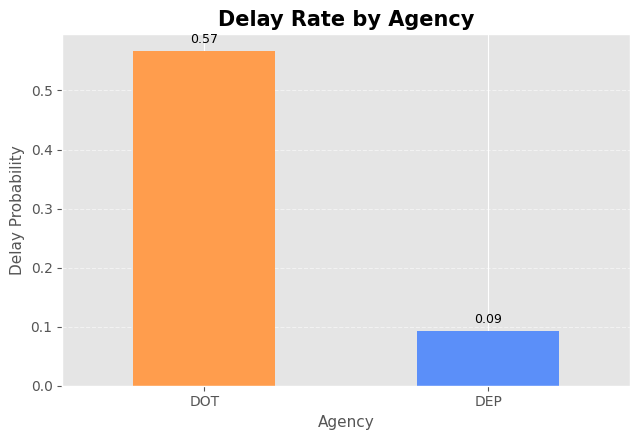


Complaint Type vs Delay contingency table:
is_delayed                             0      1
Problem (formerly Complaint Type)              
Sewer                              25159   1580
Street Light Condition             13695  17916
Water System                       73350   8464

Chi-square test: Complaint Type vs Delay
Chi2: 34728.18092926245
p-value: 0.0
Cramer's V: 0.4978
Minimum expected frequency: 5333.912


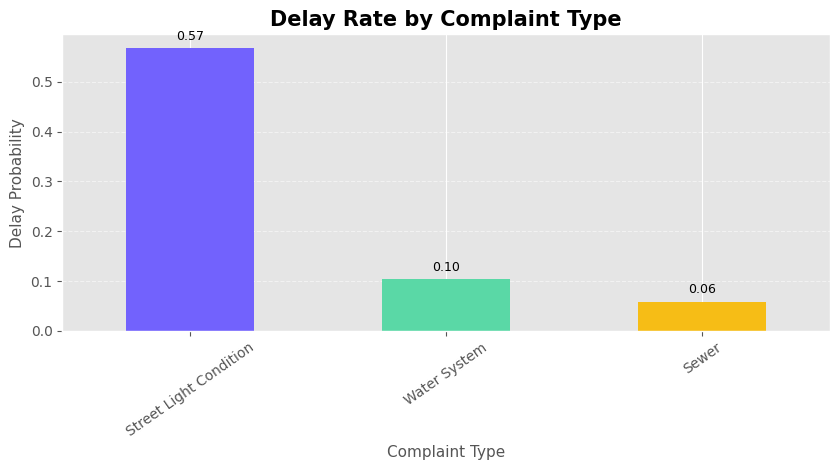

H2 Decision: Reject H0_2


In [43]:

print("\n================ H2 RESULTS ================")

# ---------------------------------------------------------
# H2A: Agency vs Delay
# ---------------------------------------------------------
agency_table = pd.crosstab(df_model["Agency"], df_model["is_delayed"])

print("\nAgency vs Delay contingency table:")
print(agency_table)

chi2_ag, p_ag, dof_ag, exp_ag = stats.chi2_contingency(agency_table)
cv_ag = cramers_v(agency_table)

print("\nChi-square test: Agency vs Delay")
print("Chi2:", chi2_ag)
print("p-value:", p_ag)
print("Cramer's V:", round(cv_ag, 4))
print("Minimum expected frequency:", round(exp_ag.min(), 4))

agency_delay_rate = (
    df_model.groupby("Agency")["is_delayed"]
    .mean()
    .sort_values(ascending=False)
)

fig, ax = plt.subplots(figsize=(6.5, 4.5))
agency_delay_rate.plot(kind="bar", ax=ax, color=["#FF9D4D", "#5B8FF9"])
ax.set_title("Delay Rate by Agency", fontsize=TITLE_SIZE, fontweight="bold")
ax.set_ylabel("Delay Probability", fontsize=LABEL_SIZE)
ax.set_xlabel("Agency", fontsize=LABEL_SIZE)
ax.tick_params(axis="x", rotation=0, labelsize=TICK_SIZE)
ax.grid(axis="y", linestyle="--", alpha=0.5)
add_bar_labels(ax, fmt="{:.2f}")
plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# H2B: Complaint Type vs Delay
# ---------------------------------------------------------
complaint_table = pd.crosstab(
    df_model["Problem (formerly Complaint Type)"],
    df_model["is_delayed"]
)

print("\nComplaint Type vs Delay contingency table:")
print(complaint_table)

chi2_ct, p_ct, dof_ct, exp_ct = stats.chi2_contingency(complaint_table)
cv_ct = cramers_v(complaint_table)

print("\nChi-square test: Complaint Type vs Delay")
print("Chi2:", chi2_ct)
print("p-value:", p_ct)
print("Cramer's V:", round(cv_ct, 4))
print("Minimum expected frequency:", round(exp_ct.min(), 4))

complaint_delay_rate = (
    df_model.groupby("Problem (formerly Complaint Type)")["is_delayed"]
    .mean()
    .sort_values(ascending=False)
)

fig, ax = plt.subplots(figsize=(8.5, 4.8))
complaint_delay_rate.plot(kind="bar", ax=ax, color=["#7262FD", "#5AD8A6", "#F6BD16"])
ax.set_title("Delay Rate by Complaint Type", fontsize=TITLE_SIZE, fontweight="bold")
ax.set_ylabel("Delay Probability", fontsize=LABEL_SIZE)
ax.set_xlabel("Complaint Type", fontsize=LABEL_SIZE)
ax.tick_params(axis="x", rotation=35, labelsize=TICK_SIZE)
ax.grid(axis="y", linestyle="--", alpha=0.5)
add_bar_labels(ax, fmt="{:.2f}")
plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# H2 Final Decision
# ---------------------------------------------------------
if p_ag < 0.05 and p_ct < 0.05:
    print("H2 Decision: Reject H0_2")
else:
    print("H2 Decision: Fail to reject H0_2")

### Effect Size (Cramér’s V)

After performing the Chi-square test, **Cramér’s V** was calculated to measure the strength of the relationship between **Agency** and **delay status (`is_delayed`)**.

Cramér’s V is an effect size metric used for categorical variables. While the Chi-square test indicates whether a statistically significant relationship exists, Cramér’s V quantifies how strong that relationship is.

The computed value of **Cramér’s V ≈ 0.497** suggests a **moderately strong association** between the agency responsible for a service request and the probability of delayed resolution. This indicates that the agency handling a request plays an important role in determining whether the request is delayed.


### Logistic Regression Analysis

To further investigate factors influencing delayed service request resolution, a logistic regression model was applied. Logistic regression is appropriate when the dependent variable is binary. In this analysis, the target variable **`is_delayed`** indicates whether a service request experienced a delay (1 = delayed, 0 = not delayed).

Two categorical predictors were included in the model: **Agency** and **Problem (formerly Complaint Type)**. Before fitting the model, categories with extremely small counts (e.g., *Oil or Gas Spill* complaints and the *DSNY* agency) were removed because very small groups can produce unstable estimates in regression models.

Since logistic regression requires numerical input variables, the categorical predictors were converted into **dummy variables** using `pd.get_dummies()` with `drop_first=True`. This approach avoids multicollinearity by automatically selecting a **baseline category** for each variable. In this model, **DEP serves as the baseline agency** and **Sewer serves as the baseline complaint type**, meaning all other categories are interpreted relative to these reference groups.

The logistic regression model was then fitted using **scikit-learn's `LogisticRegression`**, and the resulting coefficients were converted into **odds ratios** to make interpretation more intuitive. Odds ratios greater than 1 indicate an increased likelihood of delay relative to the baseline category, while odds ratios less than 1 indicate a lower likelihood of delay.



================ H2 LOGISTIC REGRESSION RESULTS ================

Agency distribution:
Agency
DEP    108553
DOT     31611
Name: count, dtype: Int64

Complaint Type distribution:
Problem (formerly Complaint Type)
Water System              81814
Street Light Condition    31611
Sewer                     26739
Name: count, dtype: Int64

Filtered Agency distribution:
Agency
DEP    108553
DOT     31611
Name: count, dtype: Int64

Filtered Complaint Type distribution:
Problem (formerly Complaint Type)
Water System              81814
Street Light Condition    31611
Sewer                     26739
Name: count, dtype: Int64

Predictor columns:
['Agency_DOT', 'Problem (formerly Complaint Type)_Street Light Condition', 'Problem (formerly Complaint Type)_Water System']

Train size: (98114, 3)
Test size: (42050, 3)

Intercept:
-2.7786719312641095

Logistic Regression Coefficients and Odds Ratios:
                                            Variable  Coefficient  Odds_Ratio
0                         

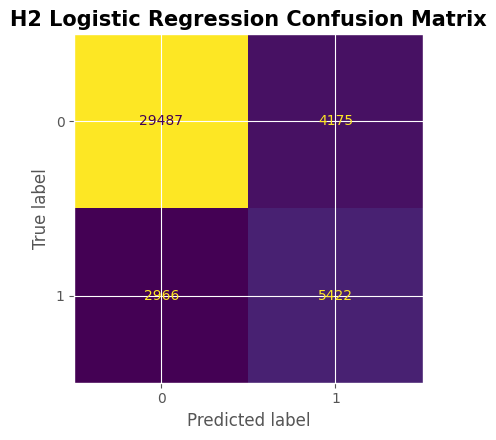

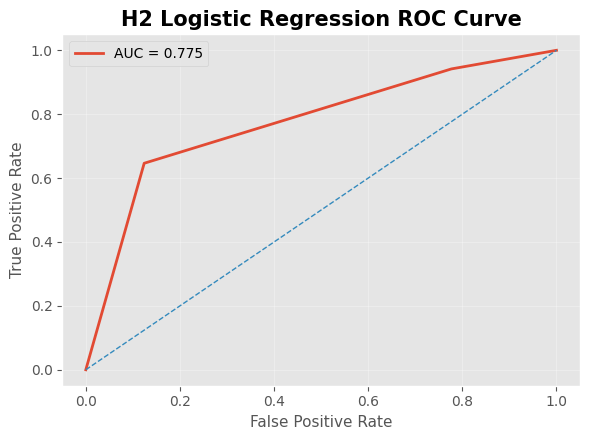


H2 Logistic Regression Decision:
The logistic regression model provides predictive evidence that agency and complaint type are associated with delayed resolution.

Interpretation Table:
                                            Variable  Coefficient  Odds_Ratio  \
0                                         Agency_DOT     1.524830    4.594364   
1  Problem (formerly Complaint Type)_Street Light...     1.524830    4.594364   
2     Problem (formerly Complaint Type)_Water System     0.628778    1.875318   

         Interpretation  
0  Higher odds of delay  
1  Higher odds of delay  
2  Higher odds of delay  


In [44]:
# =========================================================
# H2 LOGISTIC REGRESSION
# H0_2: Agency and complaint type are not significantly
#       associated with the probability of delayed resolution.
# H1_2: Agency and complaint type are significantly associated
#       with the probability of delayed resolution.
# Method: Logistic Regression
# =========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    classification_report
)

print("\n================ H2 LOGISTIC REGRESSION RESULTS ================")

# ---------------------------------------------------------
# Step 1: Check category distributions
# ---------------------------------------------------------
print("\nAgency distribution:")
print(df_model["Agency"].value_counts(dropna=False))

print("\nComplaint Type distribution:")
print(df_model["Problem (formerly Complaint Type)"].value_counts(dropna=False))

# ---------------------------------------------------------
# Step 2: Keep required columns and remove missing values
# ---------------------------------------------------------
df_lr = df_model[
    ["is_delayed", "Agency", "Problem (formerly Complaint Type)"]
].dropna().copy()

# ---------------------------------------------------------
# Step 3: Remove very rare categories
# ---------------------------------------------------------
agency_counts = df_lr["Agency"].value_counts()
complaint_counts = df_lr["Problem (formerly Complaint Type)"].value_counts()

valid_agencies = agency_counts[agency_counts >= 20].index
valid_complaints = complaint_counts[complaint_counts >= 20].index

df_lr = df_lr[
    df_lr["Agency"].isin(valid_agencies) &
    df_lr["Problem (formerly Complaint Type)"].isin(valid_complaints)
].copy()

print("\nFiltered Agency distribution:")
print(df_lr["Agency"].value_counts())

print("\nFiltered Complaint Type distribution:")
print(df_lr["Problem (formerly Complaint Type)"].value_counts())

# ---------------------------------------------------------
# Step 4: Create dummy variables
# Baseline categories will be the first dropped categories
# ---------------------------------------------------------
df_lr = pd.get_dummies(
    df_lr,
    columns=["Agency", "Problem (formerly Complaint Type)"],
    drop_first=True,
    dtype=int
)

# ---------------------------------------------------------
# Step 5: Define predictors and target
# ---------------------------------------------------------
X = df_lr.drop("is_delayed", axis=1)
y = df_lr["is_delayed"]

print("\nPredictor columns:")
print(X.columns.tolist())

# ---------------------------------------------------------
# Step 6: Train/Test Split
# ---------------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

print("\nTrain size:", X_train.shape)
print("Test size:", X_test.shape)

# ---------------------------------------------------------
# Step 7: Fit Logistic Regression
# ---------------------------------------------------------
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train, y_train)

print("\nIntercept:")
print(model.intercept_[0])

# ---------------------------------------------------------
# Step 8: Coefficients and Odds Ratios
# ---------------------------------------------------------
results = pd.DataFrame({
    "Variable": X.columns,
    "Coefficient": model.coef_[0],
    "Odds_Ratio": np.exp(model.coef_[0])
})

results = results.sort_values(by="Odds_Ratio", ascending=False).reset_index(drop=True)

print("\nLogistic Regression Coefficients and Odds Ratios:")
print(results)

# ---------------------------------------------------------
# Step 9: Predictions
# ---------------------------------------------------------
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

# ---------------------------------------------------------
# Step 10: Evaluation Metrics
# ---------------------------------------------------------
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

print("\nModel Performance:")
print("Accuracy:", round(acc, 4))
print("Precision:", round(prec, 4))
print("Recall:", round(rec, 4))
print("F1 Score:", round(f1, 4))
print("ROC-AUC:", round(roc_auc, 4))

print("\nClassification Report:")

print(classification_report(y_test, y_pred, zero_division=0))
# ---------------------------------------------------------
# Step 11: Confusion Matrix
# ---------------------------------------------------------
cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")
print(cm)

fig, ax = plt.subplots(figsize=(5.5, 4.5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(ax=ax, colorbar=False)
ax.set_title("H2 Logistic Regression Confusion Matrix", fontsize=TITLE_SIZE, fontweight="bold")
plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# Step 12: ROC Curve
# ---------------------------------------------------------
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

fig, ax = plt.subplots(figsize=(6, 4.5))
ax.plot(fpr, tpr, linewidth=2, label=f"AUC = {roc_auc:.3f}")
ax.plot([0, 1], [0, 1], linestyle="--", linewidth=1)
ax.set_title("H2 Logistic Regression ROC Curve", fontsize=TITLE_SIZE, fontweight="bold")
ax.set_xlabel("False Positive Rate", fontsize=LABEL_SIZE)
ax.set_ylabel("True Positive Rate", fontsize=LABEL_SIZE)
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# Step 13: Final Decision for H2 based on logistic model
# ---------------------------------------------------------
print("\nH2 Logistic Regression Decision:")
if roc_auc > 0.5:
    print("The logistic regression model provides predictive evidence that agency and complaint type are associated with delayed resolution.")
else:
    print("The logistic regression model does not provide useful predictive evidence for delayed resolution.")

# ---------------------------------------------------------
# Step 14: Simple Interpretation Table
# ---------------------------------------------------------
interpretation = results.copy()
interpretation["Interpretation"] = interpretation["Odds_Ratio"].apply(
    lambda x: "Higher odds of delay" if x > 1 else "Lower odds of delay"
)

print("\nInterpretation Table:")
print(interpretation)

### Logistic Regression Model Performance

To evaluate the performance of the logistic regression model, a **confusion matrix** and **accuracy score** were calculated.

The model achieved an **accuracy of approximately 83%**, indicating that it correctly predicts whether a service request will be delayed in about **83 out of 100 cases**. This suggests that the model performs reasonably well in identifying delay outcomes based on the selected predictors.

Overall, this result indicates that **agency and complaint type provide meaningful information for predicting delay probability**, and the logistic regression model captures a substantial portion of the variation in delay outcomes.


In [45]:
from sklearn.metrics import confusion_matrix, accuracy_score

y_pred = model.predict(X)

confusion_matrix(y, y_pred)
accuracy_score(y, y_pred)

0.8306341143232213

### Hypothesis 2 Conclusion

The relationship between **agency / complaint type** and **delay probability** was analyzed using multiple statistical approaches.

First, a **Chi-square test of independence** was performed to examine whether delay status is associated with agency and complaint type. The results showed a statistically significant relationship, leading to the rejection of the null hypothesis.

To evaluate the strength of this association, **Cramér’s V** was calculated. The value of approximately **0.497** indicates a **moderately strong relationship**, suggesting that the agency responsible for a request has a meaningful influence on whether the request experiences delay.

A **logistic regression model** was then applied to estimate delay probability based on agency and complaint type. The results showed that requests handled by **DOT** and **street light complaints** have a significantly higher likelihood of delay compared to the baseline categories. Water system complaints also show an increased probability of delay.

The model achieved an **accuracy of approximately 83%**, indicating that agency and complaint type are useful predictors of delay outcomes.

Overall, these results provide strong evidence that **agency responsibility and complaint type significantly influence the probability of delayed service request resolution**, supporting the alternative hypothesis.


### Hypothesis 3: Impact of Temporal Factors on Delay Probability

This hypothesis examines whether time-related factors influence the likelihood of delayed service request resolution.

H₀₃: Temporal factors (weekday/weekend and season) do not significantly affect the probability of delayed resolution.

H₁₃: Temporal factors significantly affect the probability of delayed resolution.

To test this hypothesis, Chi-square tests of independence are performed between the delay status (`is_delayed`) and temporal variables such as `is_weekend`, `created_weekday`, and `season`. These tests determine whether the probability of delay varies depending on when a request is created.


================ H3 RESULTS ================

Weekend vs Delay contingency table:
is_delayed      0      1
is_weekend              
0           90636  23066
1           21568   4894

Chi-square test: Weekend vs Delay
Chi2: 43.051481241167174
p-value: 5.331823471965718e-11


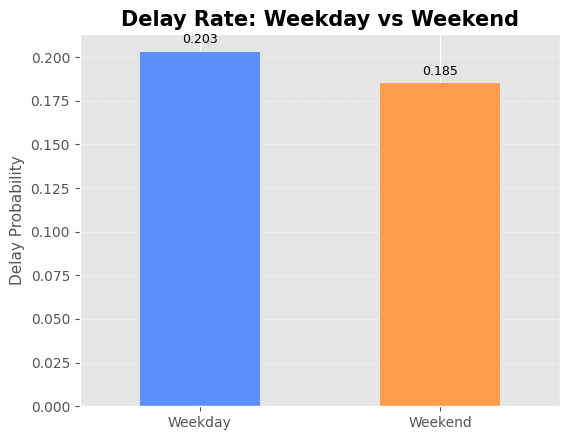


Season vs Delay contingency table:
is_delayed      0     1
season                 
Fall        20256  8607
Spring      18520  4612
Summer      44043  7332
Winter      29385  7409

Chi-square test: Season vs Delay
Chi2: 2799.029912034614
p-value: 0.0


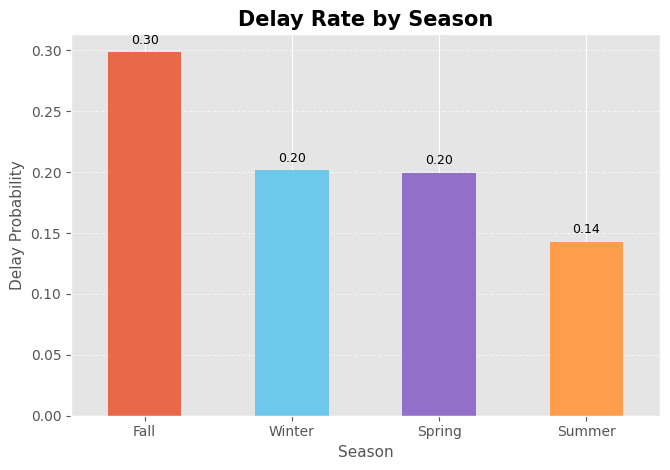

H3 Decision: Reject H0_3


In [46]:

print("\n================ H3 RESULTS ================")

# H3A: Weekend vs Delay
weekend_table = pd.crosstab(df_model["is_weekend"], df_model["is_delayed"])
print("\nWeekend vs Delay contingency table:")
print(weekend_table)

chi2_w, p_w, dof_w, exp_w = stats.chi2_contingency(weekend_table)
print("\nChi-square test: Weekend vs Delay")
print("Chi2:", chi2_w)
print("p-value:", p_w)

weekend_delay_rate = df_model.groupby("is_weekend")["is_delayed"].mean()
weekend_delay_rate.index = ["Weekday", "Weekend"]

fig, ax = plt.subplots(figsize=(5.8, 4.5))
weekend_delay_rate.plot(kind="bar", ax=ax, color=["#5B8FF9", "#FF9D4D"])
ax.set_title("Delay Rate: Weekday vs Weekend", fontsize=TITLE_SIZE, fontweight="bold")
ax.set_ylabel("Delay Probability", fontsize=LABEL_SIZE)
ax.set_xlabel("")
ax.tick_params(axis="x", rotation=0, labelsize=TICK_SIZE)
ax.grid(axis="y", linestyle="--", alpha=0.5)
add_bar_labels(ax, fmt="{:.3f}")
plt.tight_layout()
plt.show()

# H3B: Season vs Delay
season_table = pd.crosstab(df_model["season"], df_model["is_delayed"])
print("\nSeason vs Delay contingency table:")
print(season_table)

chi2_s, p_s, dof_s, exp_s = stats.chi2_contingency(season_table)
print("\nChi-square test: Season vs Delay")
print("Chi2:", chi2_s)
print("p-value:", p_s)

season_delay_rate = (
    df_model.groupby("season")["is_delayed"]
    .mean()
    .sort_values(ascending=False)
)

fig, ax = plt.subplots(figsize=(6.8, 4.8))
season_delay_rate.plot(kind="bar", ax=ax, color=["#E8684A", "#6DC8EC", "#9270CA", "#FF9D4D"])
ax.set_title("Delay Rate by Season", fontsize=TITLE_SIZE, fontweight="bold")
ax.set_ylabel("Delay Probability", fontsize=LABEL_SIZE)
ax.set_xlabel("Season", fontsize=LABEL_SIZE)
ax.tick_params(axis="x", rotation=0, labelsize=TICK_SIZE)
ax.grid(axis="y", linestyle="--", alpha=0.5)
add_bar_labels(ax, fmt="{:.2f}")
plt.tight_layout()
plt.show()

if p_w < 0.05 and p_s < 0.05:
    print("H3 Decision: Reject H0_3")
else:
    print("H3 Decision: Fail to reject H0_3")

### Effect Size Analysis (Cramér’s V)

To measure the strength of the relationship between weekend requests and delay probability, Cramér’s V was calculated.

The computed Cramér’s V value is **0.017**, which indicates a **very weak association** between weekend status and delayed resolution.

Although the Chi-square test evaluates statistical significance, Cramér’s V helps determine the practical strength of the relationship. In this case, the very low value suggests that whether a request is submitted on a weekend or weekday has **minimal practical impact on the likelihood of delays**.

This implies that temporal factors such as weekends alone are unlikely to be strong drivers of delayed service request resolution.

### Effect Size Analysis (Cramér’s V) – Season vs Delay

To evaluate the strength of the relationship between seasonal factors and delayed resolution, Cramér’s V was calculated.

The computed value of **Cramér’s V = 0.141** indicates a **weak association** between the season in which a service request is submitted and the probability of delayed resolution.

While the Chi-square test evaluates whether a statistically significant relationship exists, Cramér’s V measures the practical strength of that relationship. The result suggests that seasonal factors have a **small but noticeable influence** on delay probability, though the effect is not strong.

This indicates that operational factors may play a more significant role in delays compared to temporal seasonal variations.

### Machine Learning Analysis for Hypothesis 3

To further evaluate whether temporal factors influence delay probability, machine learning models were applied using temporal features including `is_weekend`, `season`, `created_weekday`, and `created_month`.

A Random Forest classifier achieved an overall accuracy of approximately **80%**. However, the confusion matrix revealed that the model predicted nearly all observations as the majority class (not delayed), failing to correctly identify delayed cases.

This indicates that temporal variables alone provide limited predictive power for identifying delayed service requests.

Feature importance analysis shows that **created_month** contributes the most to the prediction, followed by **seasonal indicators such as summer and winter**, while **weekend effects have minimal influence**.

Overall, the machine learning results reinforce the statistical findings from the Chi-square and Cramér’s V analyses, suggesting that while temporal factors may show statistically detectable associations with delays, their practical impact on predicting delayed resolution is relatively weak.

Encoded dataset info:
<class 'pandas.core.frame.DataFrame'>
Index: 140300 entries, 13 to 149479
Data columns (total 12 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   is_delayed                 140300 non-null  Int64  
 1   is_weekend                 140300 non-null  int64  
 2   created_month              140300 non-null  int32  
 3   season_Spring              140300 non-null  boolean
 4   season_Summer              140300 non-null  boolean
 5   season_Winter              140300 non-null  boolean
 6   created_weekday_Monday     140300 non-null  bool   
 7   created_weekday_Saturday   140300 non-null  bool   
 8   created_weekday_Sunday     140300 non-null  bool   
 9   created_weekday_Thursday   140300 non-null  bool   
 10  created_weekday_Tuesday    140300 non-null  bool   
 11  created_weekday_Wednesday  140300 non-null  bool   
dtypes: Int64(1), bool(6), boolean(3), int32(1), int64(1)
memory usage: 5

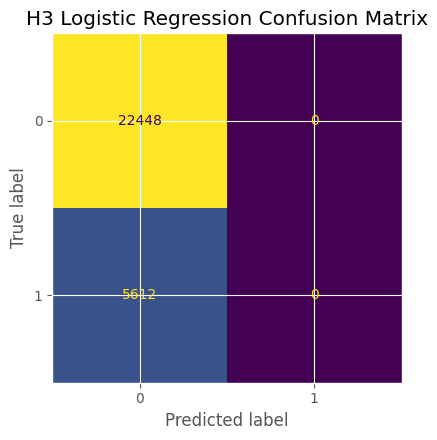

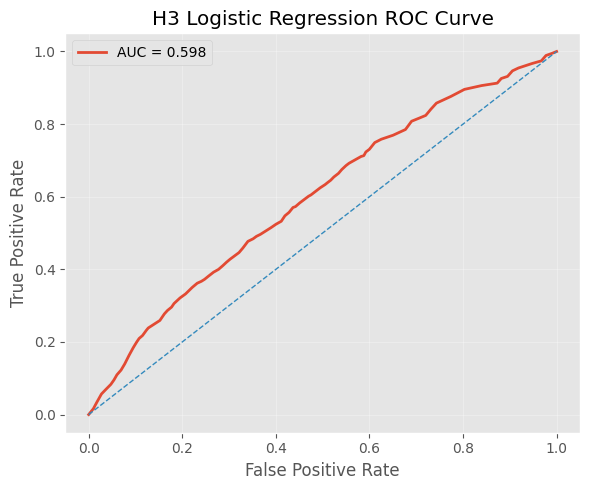


================ RANDOM FOREST ================
Threshold used: 0.3
Accuracy: 0.2527
ROC-AUC: 0.6459
Confusion Matrix:
[[ 1575 20873]
 [   97  5515]]
Classification Report:
              precision    recall  f1-score   support

         0.0       0.94      0.07      0.13     22448
         1.0       0.21      0.98      0.34      5612

    accuracy                           0.25     28060
   macro avg       0.58      0.53      0.24     28060
weighted avg       0.80      0.25      0.17     28060



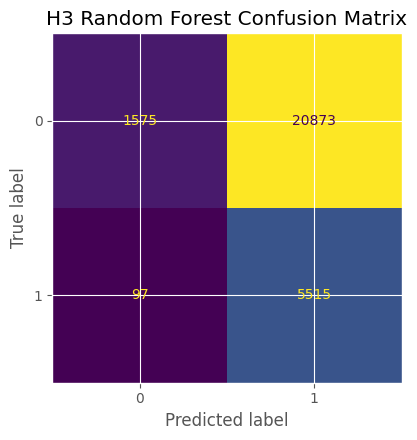

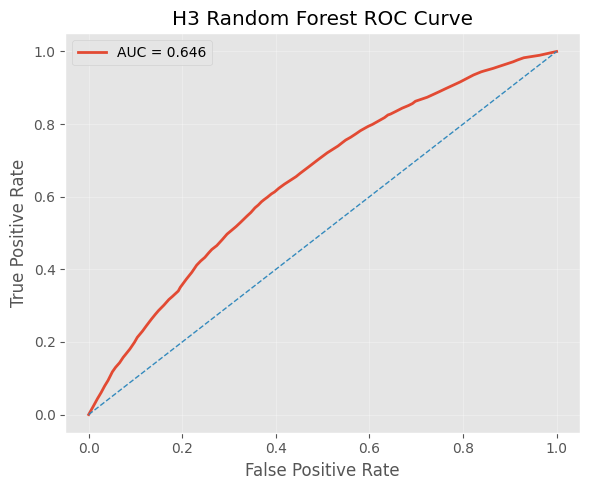


Top Random Forest Feature Importances:
created_month                0.636506
season_Summer                0.200441
season_Winter                0.039040
season_Spring                0.030327
created_weekday_Tuesday      0.021784
created_weekday_Wednesday    0.017296
created_weekday_Thursday     0.016102
created_weekday_Monday       0.014278
is_weekend                   0.011118
created_weekday_Saturday     0.009021
dtype: float64


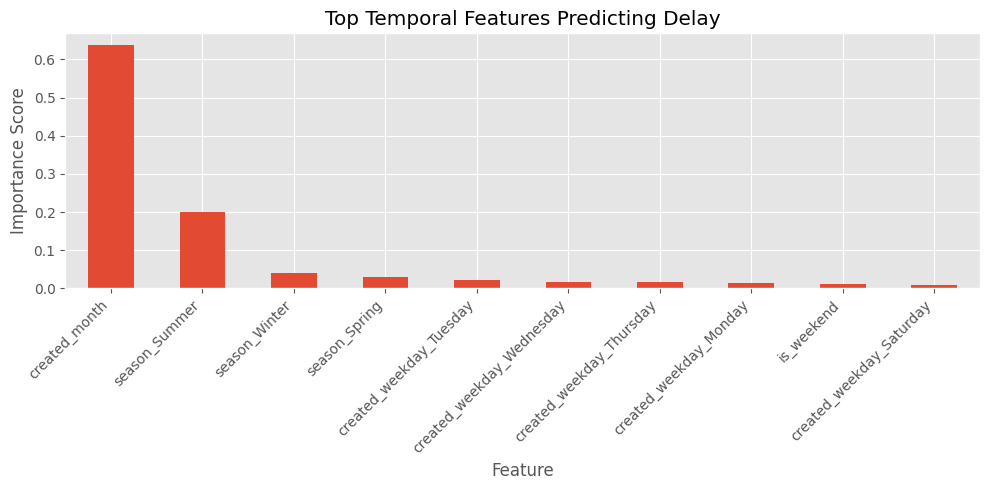

In [47]:
# ============================================================
# H3 - Machine Learning: Temporal Factors -> Delay Prediction
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    roc_curve,
    roc_auc_score
)

# ------------------------------------------------------------
# Step 1: Create a separate ML dataset
# ------------------------------------------------------------
df_ml = df[
    ['is_delayed', 'is_weekend', 'season', 'created_weekday', 'created_month']
].dropna().copy()

# ------------------------------------------------------------
# Step 2: Convert categorical variables into dummy variables
# ------------------------------------------------------------
df_ml_encoded = pd.get_dummies(
    df_ml,
    columns=['season', 'created_weekday'],
    drop_first=True
)

print("Encoded dataset info:")
df_ml_encoded.info()

print("\nTarget distribution:")
print(df_ml_encoded['is_delayed'].value_counts(normalize=True))

# ------------------------------------------------------------
# Step 3: Define features and target
# ------------------------------------------------------------
X = df_ml_encoded.drop('is_delayed', axis=1)
y = df_ml_encoded['is_delayed']

# ------------------------------------------------------------
# Step 4: Train-test split
# ------------------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# ------------------------------------------------------------
# Step 5: Logistic Regression
# ------------------------------------------------------------
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train, y_train)

y_pred_lr = lr_model.predict(X_test)
y_prob_lr = lr_model.predict_proba(X_test)[:, 1]

lr_acc = accuracy_score(y_test, y_pred_lr)
lr_cm = confusion_matrix(y_test, y_pred_lr)
lr_auc = roc_auc_score(y_test, y_prob_lr)

print("\n================ LOGISTIC REGRESSION ================")
print("Accuracy:", round(lr_acc, 4))
print("ROC-AUC:", round(lr_auc, 4))
print("Confusion Matrix:")
print(lr_cm)
print("Classification Report:")
print(classification_report(y_test, y_pred_lr, zero_division=0))

# Logistic Regression coefficients
lr_results = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": lr_model.coef_[0],
    "Odds_Ratio": np.exp(lr_model.coef_[0])
}).sort_values(by="Coefficient", ascending=False)

print("\nTop Logistic Regression Coefficients:")
print(lr_results.head(10))

# ------------------------------------------------------------
# Step 6: Logistic Regression Confusion Matrix Plot
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(5.5, 4.5))
ConfusionMatrixDisplay(confusion_matrix=lr_cm).plot(ax=ax, colorbar=False)
ax.set_title("H3 Logistic Regression Confusion Matrix")
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Step 7: Logistic Regression ROC Curve
# ------------------------------------------------------------
fpr, tpr, _ = roc_curve(y_test, y_prob_lr)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, linewidth=2, label=f"AUC = {lr_auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle='--', linewidth=1)
plt.title("H3 Logistic Regression ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Step 8: Random Forest
# ------------------------------------------------------------
rf_model = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight="balanced_subsample",
    min_samples_leaf=5,
    max_depth=10
)

rf_model.fit(X_train, y_train)

# Predicted probabilities
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

# Lower threshold to improve delayed-case detection
threshold = 0.30
y_pred_rf = (y_prob_rf >= threshold).astype(int)

rf_acc = accuracy_score(y_test, y_pred_rf)
rf_cm = confusion_matrix(y_test, y_pred_rf)
rf_auc = roc_auc_score(y_test, y_prob_rf)

print("\n================ RANDOM FOREST ================")
print("Threshold used:", threshold)
print("Accuracy:", round(rf_acc, 4))
print("ROC-AUC:", round(rf_auc, 4))
print("Confusion Matrix:")
print(rf_cm)
print("Classification Report:")
print(classification_report(y_test, y_pred_rf))

# ------------------------------------------------------------
# Step 9: Random Forest Confusion Matrix Plot
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(5.5, 4.5))
ConfusionMatrixDisplay(confusion_matrix=rf_cm).plot(ax=ax, colorbar=False)
ax.set_title("H3 Random Forest Confusion Matrix")
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Step 10: Random Forest ROC Curve
# ------------------------------------------------------------
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)

plt.figure(figsize=(6, 5))
plt.plot(fpr_rf, tpr_rf, linewidth=2, label=f"AUC = {rf_auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle='--', linewidth=1)
plt.title("H3 Random Forest ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Step 11: Feature Importance from Random Forest
# ------------------------------------------------------------
feature_importance = pd.Series(
    rf_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print("\nTop Random Forest Feature Importances:")
print(feature_importance.head(10))

# ------------------------------------------------------------
# Step 12: Plot Top 10 Feature Importances
# ------------------------------------------------------------
plt.figure(figsize=(10, 5))
feature_importance.head(10).plot(kind='bar')
plt.title("Top Temporal Features Predicting Delay")
plt.ylabel("Importance Score")
plt.xlabel("Feature")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Hypothesis 3 Conclusion

Hypothesis 3 examined whether temporal factors such as weekend status and seasonal variations influence the probability of delayed service request resolution.

The Chi-square tests indicated statistically significant relationships between temporal factors and delay probability. However, effect size analysis using Cramér’s V showed that the strength of these relationships is relatively weak. The association between weekend status and delay probability was extremely weak (Cramér’s V = 0.017), while the relationship between season and delay probability was weak (Cramér’s V = 0.141).

To further evaluate the predictive capability of temporal variables, machine learning models were applied using features including `is_weekend`, `season`, `created_weekday`, and `created_month`. Although the Random Forest model achieved an overall accuracy of approximately 80%, the confusion matrix revealed that the model predominantly predicted the majority class (not delayed) and was unable to effectively identify delayed cases.

Feature importance analysis indicated that `created_month` and certain seasonal indicators contributed more to delay prediction compared to weekend status, which had minimal influence.

Overall, these findings suggest that while temporal factors show statistically detectable associations with delayed service resolution, their practical impact on predicting delays is limited. Operational factors such as agency workload or complaint type are likely more influential drivers of service request delays.

Therefore, although the null hypothesis (H₀₃) is rejected due to statistical significance, the weak effect size and limited predictive performance indicate that temporal factors have only a minor practical influence on delayed service request resolution.

In [48]:
# =========================================================
# H5
# H0_5: Agency workload has no significant effect on delay probability.
# H1_5: Higher agency workload significantly increases delay probability.
# Method: Simple Logistic Regression
# =========================================================

print("\n================ H5 RESULTS ================")

model_h5 = smf.logit(
    "is_delayed ~ agency_workload_daily",
    data=df_model
).fit()

print(model_h5.summary())

h5_or_100 = np.exp(model_h5.params["agency_workload_daily"] * 100)
print("Odds ratio for +100 workload increase:", round(h5_or_100, 4))

if model_h5.pvalues["agency_workload_daily"] < 0.05 and model_h5.params["agency_workload_daily"] > 0:
    print("H5 Decision: Reject H0_5")
else:
    print("H5 Decision: Fail to reject H0_5")


================ H5 RESULTS ================
Optimization terminated successfully.
         Current function value: 0.487692
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:             is_delayed   No. Observations:               140164
Model:                          Logit   Df Residuals:                   140162
Method:                           MLE   Df Model:                            1
Date:                Tue, 17 Mar 2026   Pseudo R-squ.:                 0.02400
Time:                        21:40:22   Log-Likelihood:                -68357.
converged:                       True   LL-Null:                       -70037.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                            coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------
Intercept                -2.4736      0.

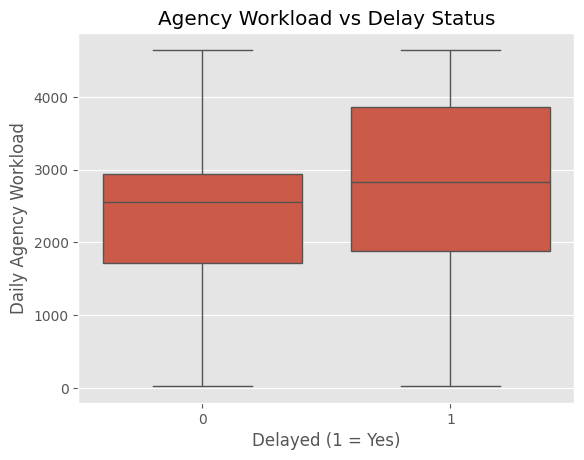

In [49]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x="is_delayed", y="agency_workload_daily", data=df_model)

plt.title("Agency Workload vs Delay Status")
plt.xlabel("Delayed (1 = Yes)")
plt.ylabel("Daily Agency Workload")
plt.show()

In [50]:
# =========================================================
# H4
# H0_4: Historical request attributes do not significantly predict delayed resolution.
# H1_4: Delayed resolution can be significantly predicted using historical request attributes.
# Method: Multivariable Logistic Regression with Train/Test Split
# =========================================================

print("\n================ H4 RESULTS ================")


# Time-based split
df_model = df_model.sort_values("Created Date")

cutoff_date = df_model["Created Date"].quantile(0.70)

train_df = df_model[df_model["Created Date"] <= cutoff_date].copy()
test_df  = df_model[df_model["Created Date"] > cutoff_date].copy()

print("Train size:", train_df.shape)
print("Test size:", test_df.shape)

model_h4 = smf.logit(
    "is_delayed ~ agency_workload_daily + C(Borough) + C(Q('Problem (formerly Complaint Type)')) + is_weekend + C(season)",
    data=train_df
).fit()

print(model_h4.summary())


================ H4 RESULTS ================
Train size: (98115, 32)
Test size: (42049, 32)
Optimization terminated successfully.
         Current function value: 0.377189
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:             is_delayed   No. Observations:                98115
Model:                          Logit   Df Residuals:                    98103
Method:                           MLE   Df Model:                           11
Date:                Tue, 17 Mar 2026   Pseudo R-squ.:                  0.1882
Time:                        21:40:25   Log-Likelihood:                -37008.
converged:                       True   LL-Null:                       -45585.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                                                          coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------

In [51]:
# =========================================================
# H4 DIAGNOSTIC CHECK: VIF
# Checks multicollinearity among numeric predictors
# =========================================================

from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_df = train_df[["agency_workload_daily", "is_weekend"]].copy()

vif_results = pd.DataFrame()
vif_results["Variable"] = vif_df.columns
vif_results["VIF"] = [
    variance_inflation_factor(vif_df.values, i)
    for i in range(vif_df.shape[1])
]

print("\nVIF Results:")
print(vif_results)


VIF Results:
                Variable       VIF
0  agency_workload_daily  1.204413
1             is_weekend  1.204413


In [52]:
# =========================================================
# H4 INTERPRETABLE OUTPUT: ODDS RATIOS
# Converts logistic coefficients into odds ratios
# =========================================================

odds_ratios = pd.DataFrame({
    "Feature": model_h4.params.index,
    "Coefficient": model_h4.params.values,
    "Odds_Ratio": np.exp(model_h4.params.values),
    "P_Value": model_h4.pvalues.values
})

print("\nOdds Ratio Table:")
print(odds_ratios.sort_values("Odds_Ratio", ascending=False))


Odds Ratio Table:
                                              Feature  Coefficient  \
5   C(Q('Problem (formerly Complaint Type)'))[T.St...     2.660527   
4                         C(Borough)[T.STATEN ISLAND]     0.778230   
3                                C(Borough)[T.QUEENS]     0.766321   
6   C(Q('Problem (formerly Complaint Type)'))[T.Wa...     0.623234   
9                                 C(season)[T.Winter]     0.419682   
1                              C(Borough)[T.BROOKLYN]     0.309121   
10                              agency_workload_daily     0.000520   
11                                         is_weekend    -0.044610   
7                                 C(season)[T.Spring]    -0.132464   
8                                 C(season)[T.Summer]    -0.511111   
2                             C(Borough)[T.MANHATTAN]    -0.588161   
0                                           Intercept    -3.927433   

    Odds_Ratio        P_Value  
5    14.303818   0.000000e+00  
4     

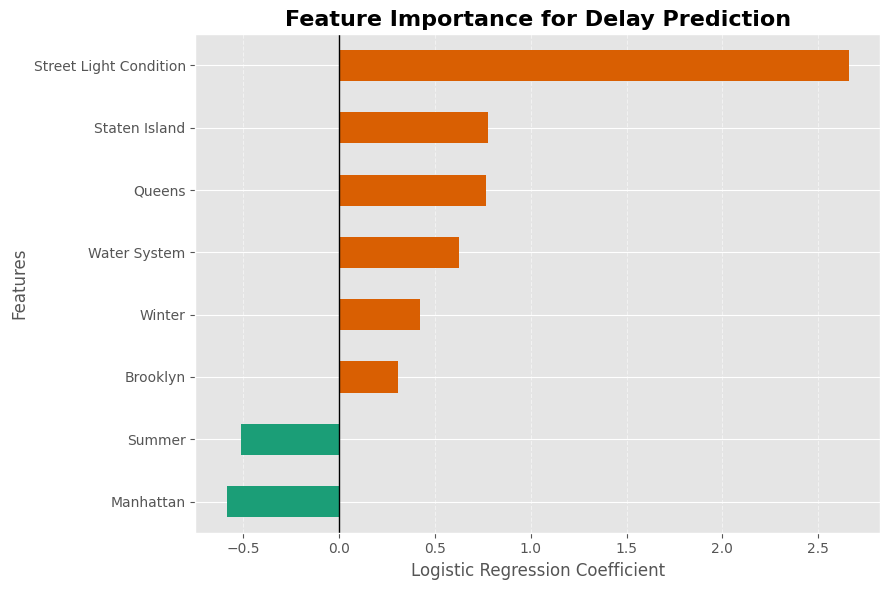

In [53]:
# =========================================================
# H4 FEATURE IMPORTANCE
# =========================================================


coef = model_h4.params.drop("Intercept")
coef_sorted = coef.reindex(
    coef.abs().sort_values(ascending=False).index
).head(8).sort_values()

feature_map = {
    "C(Q('Problem (formerly Complaint Type)'))[T.Street Light Condition]": "Street Light Condition",
    "C(Q('Problem (formerly Complaint Type)'))[T.Water System]": "Water System",
    "C(Borough)[T.STATEN ISLAND]": "Staten Island",
    "C(Borough)[T.QUEENS]": "Queens",
    "C(Borough)[T.BROOKLYN]": "Brooklyn",
    "C(Borough)[T.MANHATTAN]": "Manhattan",
    "C(season)[T.Spring]": "Spring",
    "C(season)[T.Summer]": "Summer",
    "C(season)[T.Winter]": "Winter",
    "agency_workload_daily": "Agency Workload",
    "is_weekend": "Weekend"
}

coef_sorted.index = coef_sorted.index.map(lambda x: feature_map.get(x, x))

plt.figure(figsize=(9,6))
colors = ["#d95f02" if v > 0 else "#1b9e77" for v in coef_sorted]

coef_sorted.plot(
    kind="barh",
    color=colors
)

plt.title("Feature Importance for Delay Prediction", fontsize=16, fontweight="bold")
plt.xlabel("Logistic Regression Coefficient")
plt.ylabel("Features")
plt.axvline(0, color="black", linewidth=1)
plt.grid(axis="x", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()


Confusion Matrix:
[[26954  4361]
 [ 2462  8272]]


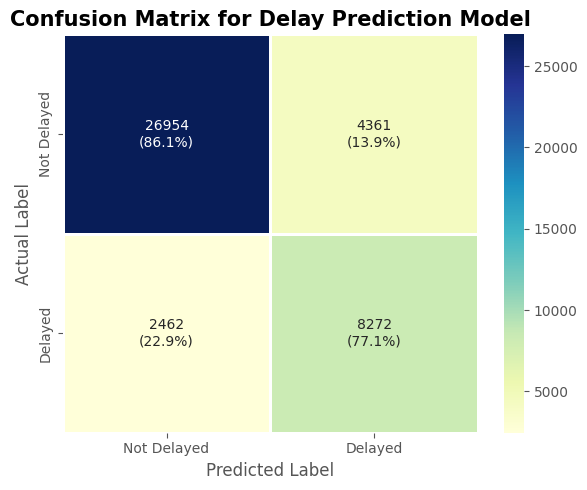


Classification Report:
              precision    recall  f1-score   support

         0.0       0.92      0.86      0.89     31315
         1.0       0.65      0.77      0.71     10734

    accuracy                           0.84     42049
   macro avg       0.79      0.82      0.80     42049
weighted avg       0.85      0.84      0.84     42049


Model AUC: 0.8477353131199793


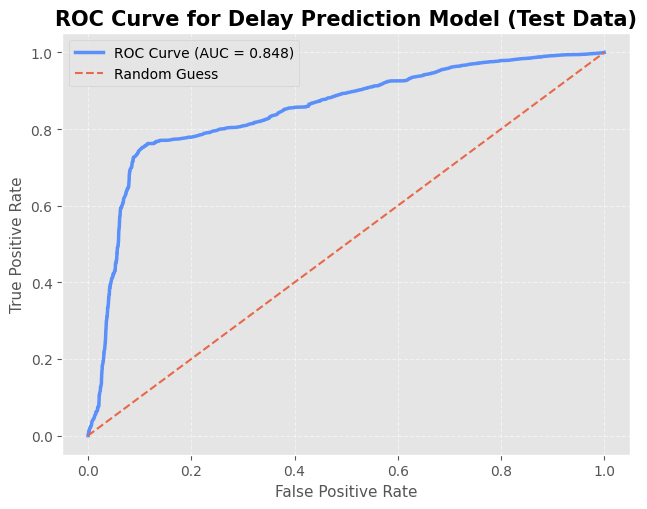

H4 Decision: Reject H0_4


In [54]:
# =========================================================
# H4 MODEL EVALUATION
# =========================================================

test_df["delay_prob"] = model_h4.predict(test_df)
test_df["delay_pred"] = (test_df["delay_prob"] > 0.5).astype(int)

cm = confusion_matrix(test_df["is_delayed"], test_df["delay_pred"])
print("\nConfusion Matrix:")
print(cm)

cm_percent = cm / cm.sum(axis=1).reshape(-1, 1)

labels = np.array([
    f"{cm[0,0]}\n({cm_percent[0,0]:.1%})",
    f"{cm[0,1]}\n({cm_percent[0,1]:.1%})",
    f"{cm[1,0]}\n({cm_percent[1,0]:.1%})",
    f"{cm[1,1]}\n({cm_percent[1,1]:.1%})"
]).reshape(2,2)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=labels,
    fmt="",
    cmap="YlGnBu",
    cbar=True,
    linewidths=1,
    linecolor="white",
    xticklabels=["Not Delayed", "Delayed"],
    yticklabels=["Not Delayed", "Delayed"]
)
plt.title("Confusion Matrix for Delay Prediction Model", fontsize=15, fontweight="bold")
plt.xlabel("Predicted Label", fontsize=12)
plt.ylabel("Actual Label", fontsize=12)
plt.tight_layout()
plt.show()

print("\nClassification Report:")
print(classification_report(test_df["is_delayed"], test_df["delay_pred"]))

auc = roc_auc_score(test_df["is_delayed"], test_df["delay_prob"])
print("\nModel AUC:", auc)

fpr, tpr, thresholds = roc_curve(test_df["is_delayed"], test_df["delay_prob"])

fig, ax = plt.subplots(figsize=(6.5, 5.2))
ax.plot(fpr, tpr, linewidth=2.5, label=f"ROC Curve (AUC = {auc:.3f})", color="#5B8FF9")
ax.plot([0, 1], [0, 1], linestyle="--", linewidth=1.5, color="#E8684A", label="Random Guess")
ax.set_xlabel("False Positive Rate", fontsize=LABEL_SIZE)
ax.set_ylabel("True Positive Rate", fontsize=LABEL_SIZE)
ax.set_title("ROC Curve for Delay Prediction Model (Test Data)", fontsize=TITLE_SIZE, fontweight="bold")
ax.legend()
ax.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

if auc > 0.70:
    print("H4 Decision: Reject H0_4")
else:
    print("H4 Decision: Fail to reject H0_4")


================ DECISION TREE RESULTS ================

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.92      0.91     31315
           1       0.76      0.71      0.73     10734

    accuracy                           0.87     42049
   macro avg       0.83      0.82      0.82     42049
weighted avg       0.87      0.87      0.87     42049

Decision Tree AUC: 0.8643

Confusion Matrix:
[[28915  2400]
 [ 3109  7625]]


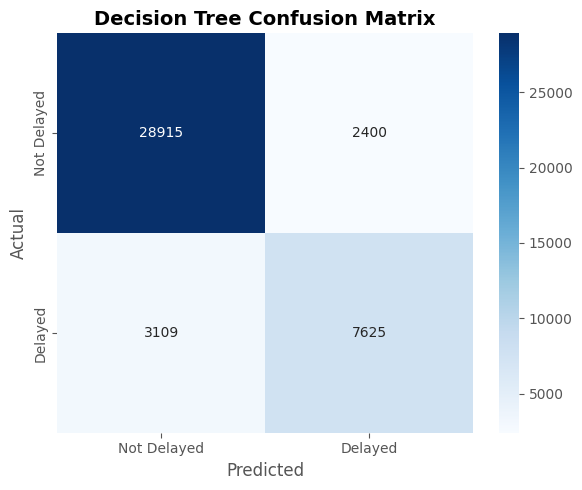

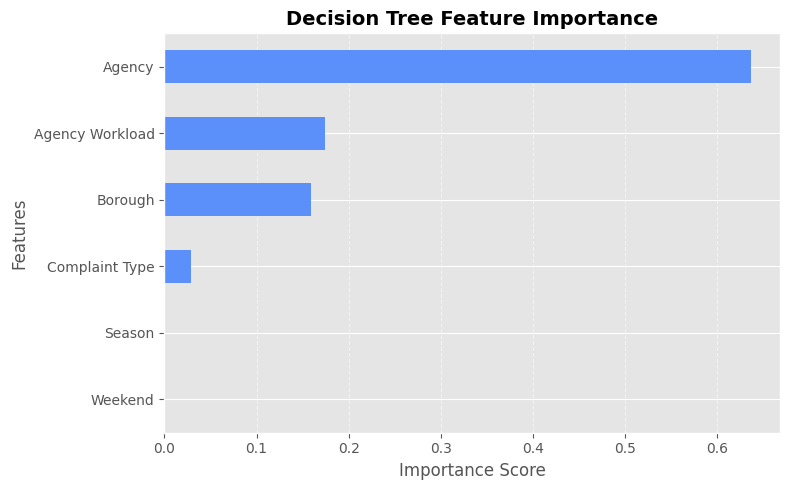

In [55]:
# =========================================================
# OPTIONAL ADDITIONAL ADVANCED METHOD
# Decision Tree Classification
# =========================================================

from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.preprocessing import LabelEncoder

df_tree = df_model.copy()

tree_cols = [
    "Agency",
    "Borough",
    "Problem (formerly Complaint Type)",
    "season",
    "is_weekend",
    "agency_workload_daily",
    "is_delayed"
]

df_tree = df_tree[tree_cols].dropna().copy()

encoders = {}
cat_cols = ["Agency", "Borough", "Problem (formerly Complaint Type)", "season"]

for c in cat_cols:
    le = LabelEncoder()
    df_tree[c] = le.fit_transform(df_tree[c].astype(str))
    encoders[c] = le

# Use the same train/test split created in H4

tree_train = df_tree.loc[train_df.index].copy()
tree_test = df_tree.loc[test_df.index].copy()

X_train = tree_train.drop(columns=["is_delayed"])
y_train = tree_train["is_delayed"].astype(int)

X_test = tree_test.drop(columns=["is_delayed"])
y_test = tree_test["is_delayed"].astype(int)

tree_model = DecisionTreeClassifier(
    max_depth=5,
    min_samples_split=50,
    min_samples_leaf=25,
    random_state=42
)

tree_model.fit(X_train, y_train)

tree_pred = tree_model.predict(X_test)
tree_prob = tree_model.predict_proba(X_test)[:, 1]

print("\n================ DECISION TREE RESULTS ================")
print("\nClassification Report:")
print(classification_report(y_test, tree_pred))

tree_auc = roc_auc_score(y_test, tree_prob)
print("Decision Tree AUC:", round(tree_auc, 4))

tree_cm = confusion_matrix(y_test, tree_pred)
print("\nConfusion Matrix:")
print(tree_cm)

plt.figure(figsize=(6,5))
sns.heatmap(
    tree_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Not Delayed", "Delayed"],
    yticklabels=["Not Delayed", "Delayed"]
)
plt.title("Decision Tree Confusion Matrix", fontsize=14, fontweight="bold")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

tree_importance = pd.Series(
    tree_model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=True)


tree_feature_map = {
    "Agency": "Agency",
    "Borough": "Borough",
    "Problem (formerly Complaint Type)": "Complaint Type",
    "season": "Season",
    "is_weekend": "Weekend",
    "agency_workload_daily": "Agency Workload"
}

tree_importance.index = [tree_feature_map.get(i, i) for i in tree_importance.index]

plt.figure(figsize=(8,5))
tree_importance.plot(kind="barh", color="#5B8FF9")
plt.title("Decision Tree Feature Importance", fontsize=14, fontweight="bold")
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.grid(axis="x", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

In [56]:
# =========================================================
# MODEL COMPARISON TABLE
# Compare Logistic Regression and Decision Tree
# =========================================================

comparison_df = pd.DataFrame({
    "Model": ["Logistic Regression", "Decision Tree"],
    "Accuracy": [
        (test_df["is_delayed"] == test_df["delay_pred"]).mean(),
        (y_test == tree_pred).mean()
    ],
    "AUC": [
        auc,
        tree_auc
    ]
})

print("\nModel Comparison:")
print(comparison_df)


Model Comparison:
                 Model  Accuracy       AUC
0  Logistic Regression  0.837737  0.847735
1        Decision Tree  0.868986  0.864326


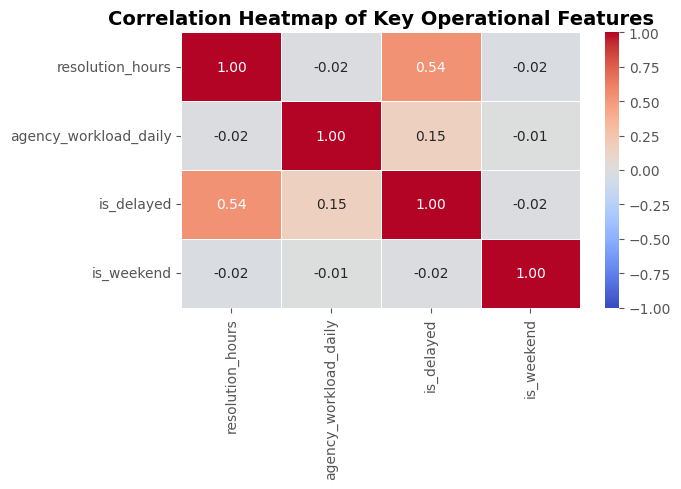

In [57]:
# =========================================================
# CORRELATION HEATMAP
# Shows relationships between numeric features
# Useful for report interpretation
# =========================================================

import seaborn as sns

corr_features = [
    "resolution_hours",
    "agency_workload_daily",
    "is_delayed",
    "is_weekend"
]

corr_df = df_model[corr_features].corr()

plt.figure(figsize=(7,5))

sns.heatmap(
    corr_df,
    annot=True,
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    fmt=".2f",
    vmin=-1,
    vmax=1
)

plt.title("Correlation Heatmap of Key Operational Features",
          fontsize=14, fontweight="bold")

plt.tight_layout()
plt.show()

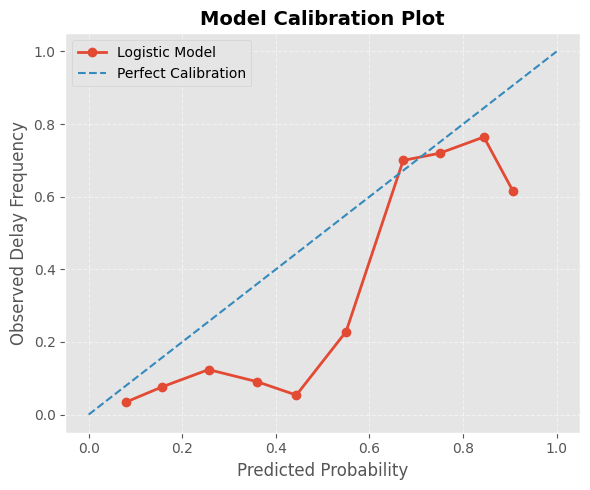

In [58]:
# =========================================================
# MODEL CALIBRATION PLOT
# Shows how well predicted probabilities match real outcomes
# =========================================================

from sklearn.calibration import calibration_curve

prob_true, prob_pred = calibration_curve(
    test_df["is_delayed"],
    test_df["delay_prob"],
    n_bins=10
)

plt.figure(figsize=(6,5))

plt.plot(prob_pred, prob_true,
         marker="o",
         label="Logistic Model",
         linewidth=2)

plt.plot([0,1],[0,1],
         linestyle="--",
         label="Perfect Calibration")

plt.xlabel("Predicted Probability")
plt.ylabel("Observed Delay Frequency")
plt.title("Model Calibration Plot", fontsize=14, fontweight="bold")

plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

Saving Final Datasets

The processed datasets were saved for further analysis and modeling. This includes the full feature dataset, the cleaned modeling dataset, and test predictions.

Key Insight: Saving these files ensures reproducibility and allows reuse for future analysis and model evaluation.

In [59]:
# =========================================================
# SAVE FINAL ANALYSIS FILES
# =========================================================

df.to_csv("311_final_features.csv", index=False)
df_model.to_csv("311_model_table.csv", index=False)

import os

output_file = "311_model_test_predictions.csv"

if os.path.exists(output_file):
    print(f"{output_file} already exists. Make sure it is closed.")
else:
    test_df.to_csv(output_file, index=False)

print("\nSaved: 311_final_features.csv, 311_model_table.csv, and 311_model_test_predictions.csv")

311_model_test_predictions.csv already exists. Make sure it is closed.

Saved: 311_final_features.csv, 311_model_table.csv, and 311_model_test_predictions.csv


## Relational Database Creation (Star Schema)

The cleaned NYC 311 dataset is transformed into a relational database using a star schema design.

### Steps:
- Loaded dataset and converted `Created Date` to datetime.
- Created time features (`created_date_only`, `created_year`).

### Dimension Tables:
- **dim_agency** → Agency details  
- **dim_borough** → Borough details  
- **dim_problem_type** → Complaint types  
- **dim_time** → Date, year, month, weekday, season, weekend  

### Fact Table:
- **fact_requests** contains:
  - Keys: `agency_id`, `borough_id`, `problem_type_id`, `time_id`
  - Measures: `resolution_hours`, `resolution_days`, `is_delayed`, `agency_workload_daily`, `is_closed`

### Output:
- All tables saved into SQLite database: `nyc311_relational.db`
- Enables efficient querying and Power BI integration

In [60]:

# -----------------------------------
# Load final cleaned dataset
# -----------------------------------
df_final = pd.read_csv("311_final_features.csv", low_memory=False)

# Make sure Created Date is datetime
df_final["Created Date"] = pd.to_datetime(df_final["Created Date"], errors="coerce")

# Create a DATE column for better time dimension design
df_final["created_date_only"] = df_final["Created Date"].dt.date.astype("string")
df_final["created_year"] = df_final["Created Date"].dt.year

# -----------------------------------
# DIMENSION TABLES
# -----------------------------------

# Agency dimension
dim_agency = (
    df_final[["Agency"]]
    .drop_duplicates()
    .reset_index(drop=True)
    .rename(columns={"Agency": "agency_name"})
)
dim_agency["agency_id"] = dim_agency.index + 1

# Borough dimension
dim_borough = (
    df_final[["Borough"]]
    .drop_duplicates()
    .reset_index(drop=True)
    .rename(columns={"Borough": "borough_name"})
)
dim_borough["borough_id"] = dim_borough.index + 1

# Problem type dimension
dim_problem_type = (
    df_final[["Problem (formerly Complaint Type)"]]
    .drop_duplicates()
    .reset_index(drop=True)
    .rename(columns={"Problem (formerly Complaint Type)": "problem_type_name"})
)
dim_problem_type["problem_type_id"] = dim_problem_type.index + 1

# Time dimension (DATE LEVEL)
dim_time = (
    df_final[[
        "created_date_only",
        "created_year",
        "created_month",
        "created_weekday",
        "season",
        "is_weekend"
    ]]
    .drop_duplicates()
    .reset_index(drop=True)
    .rename(columns={
        "created_date_only": "created_date",
        "created_year": "year",
        "created_month": "month",
        "created_weekday": "weekday"
    })
)
dim_time["time_id"] = dim_time.index + 1

# -----------------------------------
# FACT TABLE
# -----------------------------------
fact_requests = df_final.copy()

fact_requests = fact_requests.merge(
    dim_agency[["agency_id", "agency_name"]],
    left_on="Agency", right_on="agency_name", how="left"
)

fact_requests = fact_requests.merge(
    dim_borough[["borough_id", "borough_name"]],
    left_on="Borough", right_on="borough_name", how="left"
)

fact_requests = fact_requests.merge(
    dim_problem_type[["problem_type_id", "problem_type_name"]],
    left_on="Problem (formerly Complaint Type)", right_on="problem_type_name", how="left"
)

fact_requests = fact_requests.merge(
    dim_time[["time_id", "created_date"]],
    left_on="created_date_only", right_on="created_date", how="left"
)

fact_requests = fact_requests[[
    "Unique Key",
    "agency_id",
    "borough_id",
    "problem_type_id",
    "time_id",
    "is_closed",
    "resolution_hours",
    "resolution_days",
    "is_delayed",
    "agency_workload_daily"
]].rename(columns={"Unique Key": "unique_key"})

# -----------------------------------
# SAVE TO SQLITE
# -----------------------------------
conn = sqlite3.connect("nyc311_relational.db")

dim_agency[["agency_id", "agency_name"]].to_sql("dim_agency", conn, if_exists="replace", index=False)
dim_borough[["borough_id", "borough_name"]].to_sql("dim_borough", conn, if_exists="replace", index=False)
dim_problem_type[["problem_type_id", "problem_type_name"]].to_sql("dim_problem_type", conn, if_exists="replace", index=False)
dim_time[["time_id", "created_date", "year", "month", "weekday", "season", "is_weekend"]].to_sql("dim_time", conn, if_exists="replace", index=False)
fact_requests.to_sql("fact_requests", conn, if_exists="replace", index=False)

tables = pd.read_sql(
    "SELECT name FROM sqlite_master WHERE type='table' ORDER BY name;",
    conn
)

print("Relational database created successfully.")
print(tables)

conn.close()

Relational database created successfully.
                           name
0                    dim_agency
1                   dim_borough
2              dim_problem_type
3                      dim_time
4                 fact_requests
5     vw_borough_problem_matrix
6               vw_geo_requests
7           vw_monthly_requests
8  vw_weekday_requests_detailed


## SQL Views

This step creates SQL views in the SQLite database to simplify analysis and reporting.

### Views Created:
- **vw_borough_summary** → Request volume, average resolution time, and delay rate by borough  
- **vw_agency_delay** → Delay performance and workload by agency  
- **vw_problem_delay** → Delay summary by problem type  
- **vw_season_delay** → Seasonal delay trends  
- **vw_weekday_delay** → Weekday vs weekend comparison  
- **vw_kpi_summary** → Overall project KPIs  

### Output:
- Existing views are dropped if already present
- New analytical views are created in `nyc311_relational.db`
- These views support easier SQL querying and Power BI dashboard development

In [61]:

conn = sqlite3.connect("nyc311_relational.db")
cur = conn.cursor()

# Drop old views if they exist
view_names = [
    "vw_borough_summary",
    "vw_agency_delay",
    "vw_problem_delay",
    "vw_season_delay",
    "vw_weekday_delay",
    "vw_kpi_summary"
]

for v in view_names:
    cur.execute(f"DROP VIEW IF EXISTS {v}")

# -----------------------------------
# 1. Borough summary
# -----------------------------------
cur.execute("""
CREATE VIEW vw_borough_summary AS
SELECT
    b.borough_name,
    COUNT(f.unique_key) AS total_requests,
    ROUND(AVG(CASE WHEN f.is_closed = 1 THEN f.resolution_hours END), 2) AS avg_resolution_hours,
    ROUND(AVG(CASE WHEN f.is_delayed IS NOT NULL THEN f.is_delayed END), 4) AS delay_rate
FROM fact_requests f
JOIN dim_borough b
    ON f.borough_id = b.borough_id
WHERE b.borough_name != 'Unspecified'
GROUP BY b.borough_name
""")

# -----------------------------------
# 2. Agency delay summary
# -----------------------------------
cur.execute("""
CREATE VIEW vw_agency_delay AS
SELECT
    a.agency_name,
    COUNT(f.unique_key) AS total_requests,
    SUM(CASE WHEN f.is_delayed = 1 THEN 1 ELSE 0 END) AS delayed_requests,
    ROUND(AVG(CASE WHEN f.is_delayed IS NOT NULL THEN f.is_delayed END), 4) AS delay_rate,
    ROUND(AVG(f.agency_workload_daily), 2) AS avg_workload
FROM fact_requests f
JOIN dim_agency a
    ON f.agency_id = a.agency_id
GROUP BY a.agency_name
HAVING COUNT(f.unique_key) >= 50
""")

# -----------------------------------
# 3. Problem type delay summary
# -----------------------------------
cur.execute("""
CREATE VIEW vw_problem_delay AS
SELECT
    p.problem_type_name,
    COUNT(f.unique_key) AS total_requests,
    SUM(CASE WHEN f.is_delayed = 1 THEN 1 ELSE 0 END) AS delayed_requests,
    ROUND(AVG(CASE WHEN f.is_delayed IS NOT NULL THEN f.is_delayed END), 4) AS delay_rate,
    ROUND(AVG(CASE WHEN f.is_closed = 1 THEN f.resolution_hours END), 2) AS avg_resolution_hours
FROM fact_requests f
JOIN dim_problem_type p
    ON f.problem_type_id = p.problem_type_id
GROUP BY p.problem_type_name
HAVING COUNT(f.unique_key) >= 50
""")

# -----------------------------------
# 4. Season delay summary
# -----------------------------------
cur.execute("""
CREATE VIEW vw_season_delay AS
SELECT
    t.season,
    COUNT(f.unique_key) AS total_requests,
    SUM(CASE WHEN f.is_delayed = 1 THEN 1 ELSE 0 END) AS delayed_requests,
    ROUND(AVG(CASE WHEN f.is_delayed IS NOT NULL THEN f.is_delayed END), 4) AS delay_rate,
    ROUND(AVG(CASE WHEN f.is_closed = 1 THEN f.resolution_hours END), 2) AS avg_resolution_hours
FROM fact_requests f
JOIN dim_time t
    ON f.time_id = t.time_id
GROUP BY t.season
""")

# -----------------------------------
# 5. Weekday / Weekend delay summary
# -----------------------------------
cur.execute("""
CREATE VIEW vw_weekday_delay AS
SELECT
    CASE
        WHEN t.is_weekend = 1 THEN 'Weekend'
        ELSE 'Weekday'
    END AS day_type,
    COUNT(f.unique_key) AS total_requests,
    SUM(CASE WHEN f.is_delayed = 1 THEN 1 ELSE 0 END) AS delayed_requests,
    ROUND(AVG(CASE WHEN f.is_delayed IS NOT NULL THEN f.is_delayed END), 4) AS delay_rate,
    ROUND(AVG(CASE WHEN f.is_closed = 1 THEN f.resolution_hours END), 2) AS avg_resolution_hours
FROM fact_requests f
JOIN dim_time t
    ON f.time_id = t.time_id
GROUP BY day_type
""")

# -----------------------------------
# 6. KPI summary view
# -----------------------------------
cur.execute("""
CREATE VIEW vw_kpi_summary AS
SELECT
    COUNT(unique_key) AS total_requests,
    SUM(CASE WHEN is_closed = 1 THEN 1 ELSE 0 END) AS closed_requests,
    SUM(CASE WHEN is_delayed = 1 THEN 1 ELSE 0 END) AS delayed_requests,
    ROUND(AVG(CASE WHEN is_closed = 1 THEN resolution_hours END), 2) AS avg_resolution_hours,
    ROUND(AVG(CASE WHEN is_delayed IS NOT NULL THEN is_delayed END), 4) AS overall_delay_rate,
    ROUND(AVG(agency_workload_daily), 2) AS avg_workload
FROM fact_requests
""")

conn.commit()

views = pd.read_sql("""
SELECT name
FROM sqlite_master
WHERE type='view'
ORDER BY name;
""", conn)

print("SQL views created successfully.")
print(views)

conn.close()

SQL views created successfully.
                 name
0     vw_agency_delay
1  vw_borough_summary
2      vw_kpi_summary
3    vw_problem_delay
4     vw_season_delay
5    vw_weekday_delay


In [62]:


conn = sqlite3.connect("nyc311_relational.db")

vw_borough_summary = pd.read_sql("SELECT * FROM vw_borough_summary", conn)
vw_agency_delay = pd.read_sql("SELECT * FROM vw_agency_delay", conn)
vw_problem_delay = pd.read_sql("SELECT * FROM vw_problem_delay", conn)
vw_season_delay = pd.read_sql("SELECT * FROM vw_season_delay", conn)
vw_weekday_delay = pd.read_sql("SELECT * FROM vw_weekday_delay", conn)
vw_kpi_summary = pd.read_sql("SELECT * FROM vw_kpi_summary", conn)

conn.close()

vw_borough_summary.to_csv("vw_borough_summary.csv", index=False)
vw_agency_delay.to_csv("vw_agency_delay.csv", index=False)
vw_problem_delay.to_csv("vw_problem_delay.csv", index=False)
vw_season_delay.to_csv("vw_season_delay.csv", index=False)
vw_weekday_delay.to_csv("vw_weekday_delay.csv", index=False)
vw_kpi_summary.to_csv("vw_kpi_summary.csv", index=False)

print("Power BI-ready files saved:")
print("- vw_borough_summary.csv")
print("- vw_agency_delay.csv")
print("- vw_problem_delay.csv")
print("- vw_season_delay.csv")
print("- vw_weekday_delay.csv")
print("- vw_kpi_summary.csv")

Power BI-ready files saved:
- vw_borough_summary.csv
- vw_agency_delay.csv
- vw_problem_delay.csv
- vw_season_delay.csv
- vw_weekday_delay.csv
- vw_kpi_summary.csv


## Advanced Power BI Tables Creation

This step prepares additional analytical tables to support advanced Power BI visualizations.

### Data Preparation:
- Loaded final dataset (`311_final_features.csv`)
- Cleaned ZIP codes, latitude, and longitude
- Converted date columns to datetime
- Created time features:
  - Year, Month, Month Name
  - Weekday, Day Type (Weekend/Weekday)
  - Month order for sorting

### Tables Created:

- **vw_geo_requests** → Detailed location-based data for maps  
- **vw_monthly_requests** → Monthly trends (for line charts)  
- **vw_weekday_requests_detailed** → Weekday vs weekend analysis  
- **vw_borough_problem_matrix** → Borough vs problem type comparison (heatmaps/matrix)

### Output:
- Tables saved in SQLite database (`nyc311_relational.db`)
- CSV files exported for Power BI:
  - `vw_geo_requests.csv`
  - `vw_monthly_requests.csv`
  - `vw_weekday_requests_detailed.csv`
  - `vw_borough_problem_matrix.csv`

### Purpose:
- Enables advanced dashboards including maps, trends, comparisons, and KPI analysis in Power BI

In [63]:
# =========================================================
# ADVANCED POWER BI TABLES FOR CAPSTONE
# ADD THIS AS A NEW CELL AFTER YOUR CURRENT SQL EXPORT CODE
# =========================================================

import pandas as pd
import sqlite3

# ---------------------------------------------------------
# LOAD FINAL FEATURE-RICH DATASET
# ---------------------------------------------------------
df_adv = pd.read_csv("311_final_features.csv", low_memory=False)

# ---------------------------------------------------------
# CLEAN INCIDENT ZIP
# Convert values like 10465.0 -> 10465
# ---------------------------------------------------------
if "Incident Zip" in df_adv.columns:
    df_adv["Incident Zip"] = (
        pd.to_numeric(df_adv["Incident Zip"], errors="coerce")
        .astype("Int64")
        .astype("string")
    )

# ---------------------------------------------------------
# DATE CONVERSION
# ---------------------------------------------------------
df_adv["Created Date"] = pd.to_datetime(df_adv["Created Date"], errors="coerce")
df_adv["Closed Date"] = pd.to_datetime(df_adv["Closed Date"], errors="coerce")

# ---------------------------------------------------------
# CREATE EXTRA TIME FEATURES
# ---------------------------------------------------------
df_adv["created_year"] = df_adv["Created Date"].dt.year
df_adv["created_month"] = df_adv["Created Date"].dt.month
df_adv["month_name"] = df_adv["Created Date"].dt.month_name()
df_adv["created_weekday"] = df_adv["Created Date"].dt.day_name()
df_adv["created_date_only"] = df_adv["Created Date"].dt.date.astype("string")

# keep weekday/weekend text version for visuals
df_adv["day_type"] = df_adv["is_weekend"].map({1: "Weekend", 0: "Weekday"})

# ordered month names for proper sorting in Power BI
month_order_map = {
    "January": 1, "February": 2, "March": 3, "April": 4,
    "May": 5, "June": 6, "July": 7, "August": 8,
    "September": 9, "October": 10, "November": 11, "December": 12
}
df_adv["month_order"] = df_adv["month_name"].map(month_order_map)

# ---------------------------------------------------------
# CLEAN LAT/LON FOR MAPS
# ---------------------------------------------------------
if "Latitude" in df_adv.columns:
    df_adv["Latitude"] = pd.to_numeric(df_adv["Latitude"], errors="coerce")

if "Longitude" in df_adv.columns:
    df_adv["Longitude"] = pd.to_numeric(df_adv["Longitude"], errors="coerce")

# ---------------------------------------------------------
# 1) GEO REQUESTS TABLE
# DETAILED TABLE FOR MAPS / LOCATION VISUALS
# ---------------------------------------------------------
geo_cols = [
    "Unique Key",
    "Created Date",
    "Agency",
    "Borough",
    "Problem (formerly Complaint Type)",
    "Problem Detail (formerly Descriptor)",
    "Incident Zip",
    "City",
    "Latitude",
    "Longitude",
    "Location",
    "resolution_hours",
    "is_closed",
    "is_delayed",
    "season",
    "created_year",
    "created_month",
    "month_name",
    "created_weekday",
    "day_type"
]

geo_cols_existing = [c for c in geo_cols if c in df_adv.columns]

vw_geo_requests = (
    df_adv[geo_cols_existing]
    .dropna(subset=["Latitude", "Longitude"], how="any")
    .copy()
)

# Optional: remove "Unspecified" borough for cleaner maps
if "Borough" in vw_geo_requests.columns:
    vw_geo_requests = vw_geo_requests[vw_geo_requests["Borough"] != "Unspecified"].copy()

# ---------------------------------------------------------
# 2) MONTHLY REQUESTS TABLE
# FOR LINE CHARTS / TIME TRENDS
# ---------------------------------------------------------
vw_monthly_requests = (
    df_adv.groupby(["created_year", "created_month", "month_name", "month_order"], dropna=False)
    .agg(
        total_requests=("Unique Key", "count"),
        closed_requests=("is_closed", "sum"),
        delayed_requests=("is_delayed", lambda x: x.fillna(0).sum()),
        avg_resolution_hours=("resolution_hours", "mean"),
        delay_rate=("is_delayed", lambda x: x.dropna().mean())
    )
    .reset_index()
    .sort_values(["created_year", "created_month"])
)

vw_monthly_requests["avg_resolution_hours"] = vw_monthly_requests["avg_resolution_hours"].round(2)
vw_monthly_requests["delay_rate"] = vw_monthly_requests["delay_rate"].round(4)

# ---------------------------------------------------------
# 3) WEEKDAY DETAILED TABLE
# FOR WEEKDAY / WEEKEND / DAY-NAME ANALYSIS
# ---------------------------------------------------------
weekday_order_map = {
    "Monday": 1, "Tuesday": 2, "Wednesday": 3, "Thursday": 4,
    "Friday": 5, "Saturday": 6, "Sunday": 7
}
df_adv["weekday_order"] = df_adv["created_weekday"].map(weekday_order_map)

vw_weekday_requests_detailed = (
    df_adv.groupby(["created_weekday", "weekday_order", "day_type"], dropna=False)
    .agg(
        total_requests=("Unique Key", "count"),
        closed_requests=("is_closed", "sum"),
        delayed_requests=("is_delayed", lambda x: x.fillna(0).sum()),
        avg_resolution_hours=("resolution_hours", "mean"),
        delay_rate=("is_delayed", lambda x: x.dropna().mean())
    )
    .reset_index()
    .sort_values("weekday_order")
)

vw_weekday_requests_detailed["avg_resolution_hours"] = vw_weekday_requests_detailed["avg_resolution_hours"].round(2)
vw_weekday_requests_detailed["delay_rate"] = vw_weekday_requests_detailed["delay_rate"].round(4)

# ---------------------------------------------------------
# 4) BOROUGH + PROBLEM CROSS TABLE
# FOR HEATMAP / MATRIX / DEEPER COMPARISON
# ---------------------------------------------------------
vw_borough_problem_matrix = (
    df_adv.groupby(["Borough", "Problem (formerly Complaint Type)"], dropna=False)
    .agg(
        total_requests=("Unique Key", "count"),
        avg_resolution_hours=("resolution_hours", "mean"),
        delay_rate=("is_delayed", lambda x: x.dropna().mean())
    )
    .reset_index()
)

vw_borough_problem_matrix["avg_resolution_hours"] = vw_borough_problem_matrix["avg_resolution_hours"].round(2)
vw_borough_problem_matrix["delay_rate"] = vw_borough_problem_matrix["delay_rate"].round(4)

# Optional: keep only meaningful groups
vw_borough_problem_matrix = vw_borough_problem_matrix[
    vw_borough_problem_matrix["total_requests"] >= 20
].copy()

# ---------------------------------------------------------
# SAVE TO SQLITE DATABASE
# ---------------------------------------------------------
conn = sqlite3.connect("nyc311_relational.db")

vw_geo_requests.to_sql("vw_geo_requests", conn, if_exists="replace", index=False)
vw_monthly_requests.to_sql("vw_monthly_requests", conn, if_exists="replace", index=False)
vw_weekday_requests_detailed.to_sql("vw_weekday_requests_detailed", conn, if_exists="replace", index=False)
vw_borough_problem_matrix.to_sql("vw_borough_problem_matrix", conn, if_exists="replace", index=False)

conn.close()

# ---------------------------------------------------------
# EXPORT CSV FILES FOR POWER BI
# ---------------------------------------------------------
vw_geo_requests.to_csv("vw_geo_requests.csv", index=False)
vw_monthly_requests.to_csv("vw_monthly_requests.csv", index=False)
vw_weekday_requests_detailed.to_csv("vw_weekday_requests_detailed.csv", index=False)
vw_borough_problem_matrix.to_csv("vw_borough_problem_matrix.csv", index=False)

# ---------------------------------------------------------
# CONFIRM OUTPUT
# ---------------------------------------------------------
print("Advanced Power BI-ready files saved:")
print("- vw_geo_requests.csv")
print("- vw_monthly_requests.csv")
print("- vw_weekday_requests_detailed.csv")
print("- vw_borough_problem_matrix.csv")

print("\nShapes:")
print("vw_geo_requests:", vw_geo_requests.shape)
print("vw_monthly_requests:", vw_monthly_requests.shape)
print("vw_weekday_requests_detailed:", vw_weekday_requests_detailed.shape)
print("vw_borough_problem_matrix:", vw_borough_problem_matrix.shape)

print("\nPreview: vw_monthly_requests")
print(vw_monthly_requests.head())

print("\nPreview: vw_weekday_requests_detailed")
print(vw_weekday_requests_detailed.head())

print("\nPreview: vw_borough_problem_matrix")
print(vw_borough_problem_matrix.head())

Advanced Power BI-ready files saved:
- vw_geo_requests.csv
- vw_monthly_requests.csv
- vw_weekday_requests_detailed.csv
- vw_borough_problem_matrix.csv

Shapes:
vw_geo_requests: (146139, 20)
vw_monthly_requests: (15, 9)
vw_weekday_requests_detailed: (7, 8)
vw_borough_problem_matrix: (16, 5)

Preview: vw_monthly_requests
   created_year  created_month month_name  month_order  total_requests  \
0          2024             12   December           12            2136   
1          2025              1    January            1           10589   
2          2025              2   February            2            9293   
3          2025              3      March            3            8329   
4          2025              4      April            4            7630   

   closed_requests  delayed_requests  avg_resolution_hours  delay_rate  
0             2055             412.0                244.07      0.2005  
1            10140            1989.0                207.60      0.1962  
2             